# Task 4: Time Series Analysis (Fedez vs. Fabri Fibra)


## Imports and Loading

In [ ]:
import os
import warnings
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import librosa
import librosa.display

from sklearn.preprocessing import LabelEncoder, Normalizer
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import Normalizer

from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance, TimeSeriesResampler
from tslearn.shapelets import LearningShapelets

from transformers import ClapModel, ClapProcessor

from feature_extractor import FeatureExtractor
from utils import *

import umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import pairwise_distances
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-muted')

In [ ]:


MP3_FOLDER = "/Users/lorenzoallegrini/Downloads/fedez_fibra"
DATASETS_FOLDER = "../datasets"

ARTIST_MAPPING = {
    "07024718": "Fedez",
    "25707984": "Fabri Fibra"
}

def get_artist_from_filename(filename):
    try:
        # Nota: La funzione lavora solo sul nome del file, non sul path intero
        artist_id = filename.split(' - ')[0].replace('ART', '')
        return ARTIST_MAPPING.get(artist_id, "Unknown")
    except:
        return "Unknown"


filenames = [f for f in os.listdir(MP3_FOLDER) if f.endswith('.mp3')]
print(f"Found {len(filenames)} MP3 files.")


fedez_files = [
    os.path.join(MP3_FOLDER, f)
    for f in filenames
    if get_artist_from_filename(f) == "Fedez"
]

fibra_files = [
    os.path.join(MP3_FOLDER, f)
    for f in filenames
    if get_artist_from_filename(f) == "Fabri Fibra"
]

all_files = fedez_files + fibra_files



Found 454 MP3 files.


In [90]:
import librosa
import numpy as np
from tqdm import tqdm
TARGET_SR = 24000

all_lengths = []
for file_path in tqdm(all_files, desc="Calcolando lunghezze"):
    try:
        y, _ = librosa.load(file_path, sr=TARGET_SR)
        all_lengths.append(len(y))
    except Exception as e:
        print(f"Errore leggendo {file_path}: {e}")

all_lengths = np.array(all_lengths)
target_length_samples = int(np.percentile(all_lengths, 95))
target_length_seconds = target_length_samples / TARGET_SR


Calcolando lunghezze: 100%|██████████| 454/454 [01:43<00:00,  4.38it/s]


--- Statistiche lunghezze audio ---
Min: 28.52s (684544 samples)
Max: 672.01s (16128209 samples)
Media: 214.26s
Mediana: 205.82s
95° percentile: 317.98s (7631586 samples)

Audio più lunghi del 95° percentile: 23 / 454


In [ ]:
print(f"\n--- Statistiche lunghezze audio ---")
print(f"Min: {all_lengths.min() / TARGET_SR:.2f}s ({all_lengths.min()} samples)")
print(f"Max: {all_lengths.max() / TARGET_SR:.2f}s ({all_lengths.max()} samples)")
print(f"Average: {all_lengths.mean() / TARGET_SR:.2f}s")
print(f"Median: {np.median(all_lengths) / TARGET_SR:.2f}s")

### visualization of the first songs

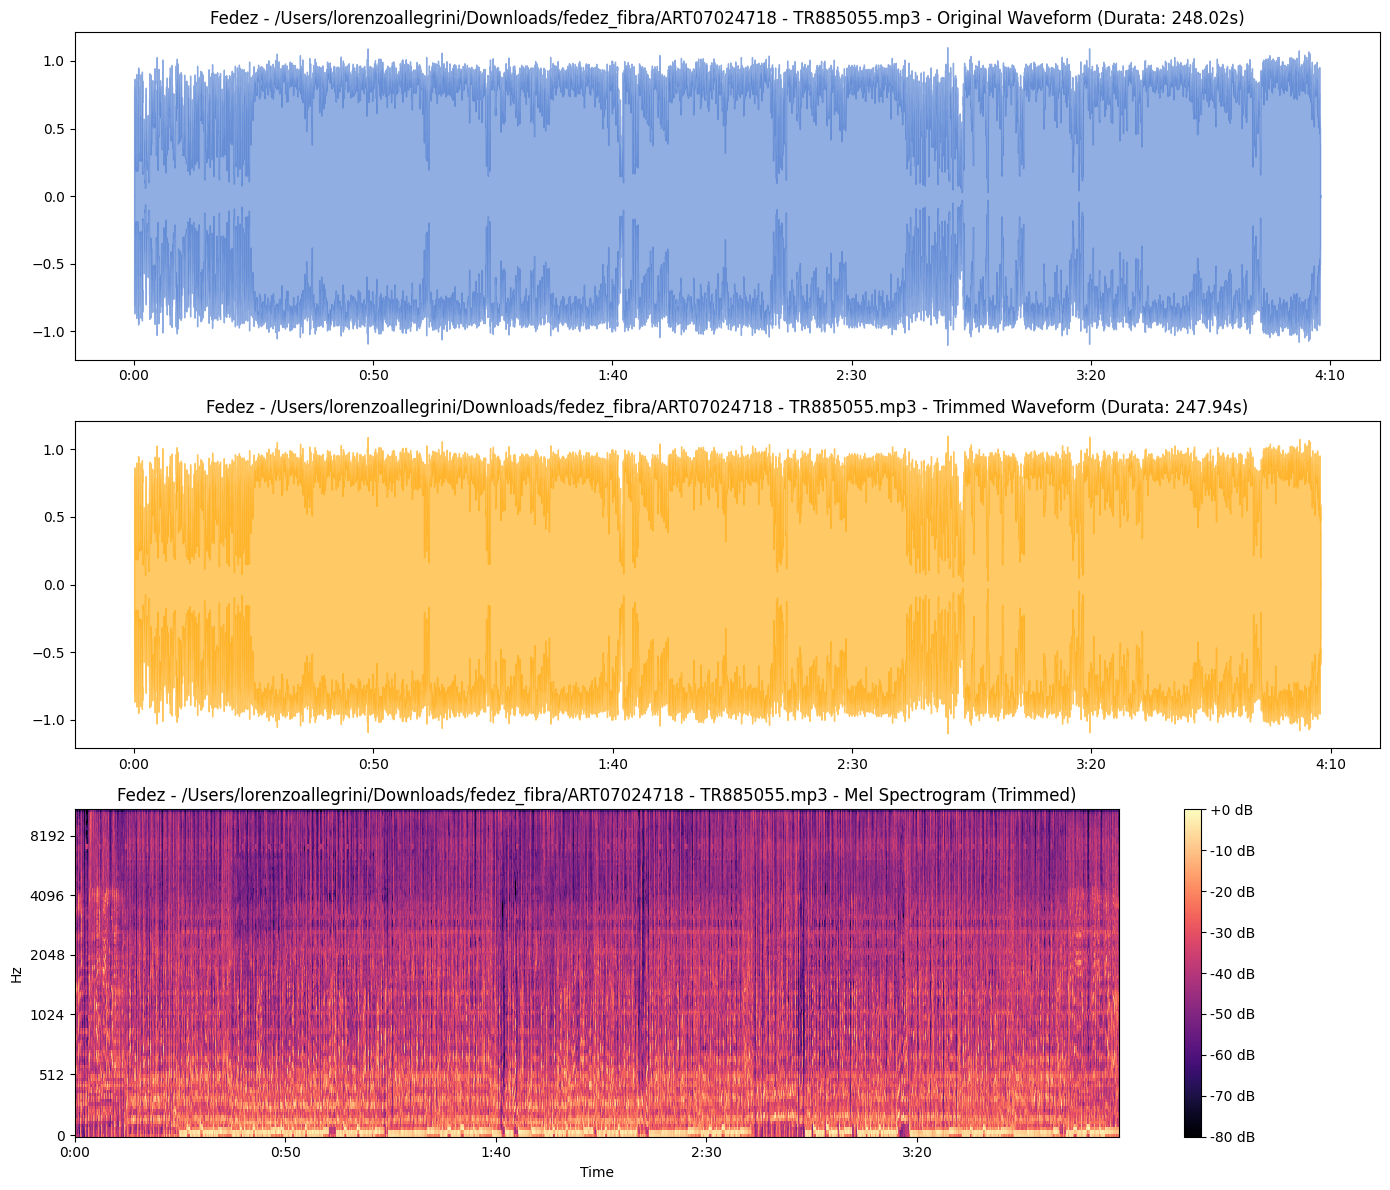

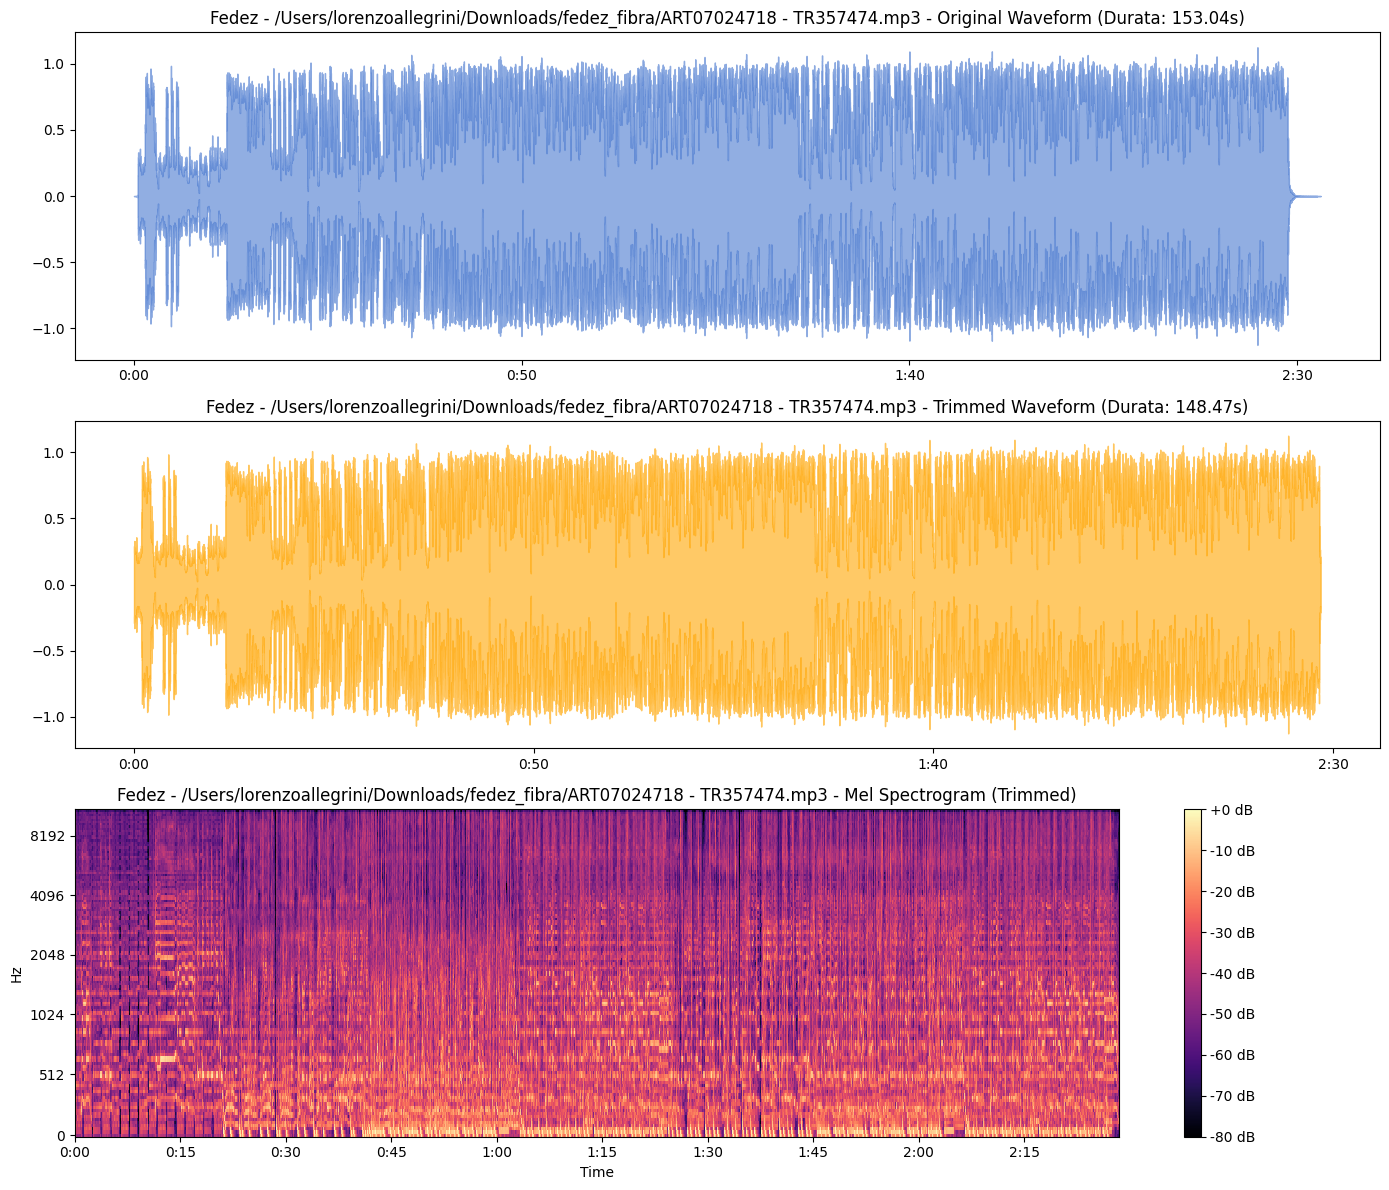

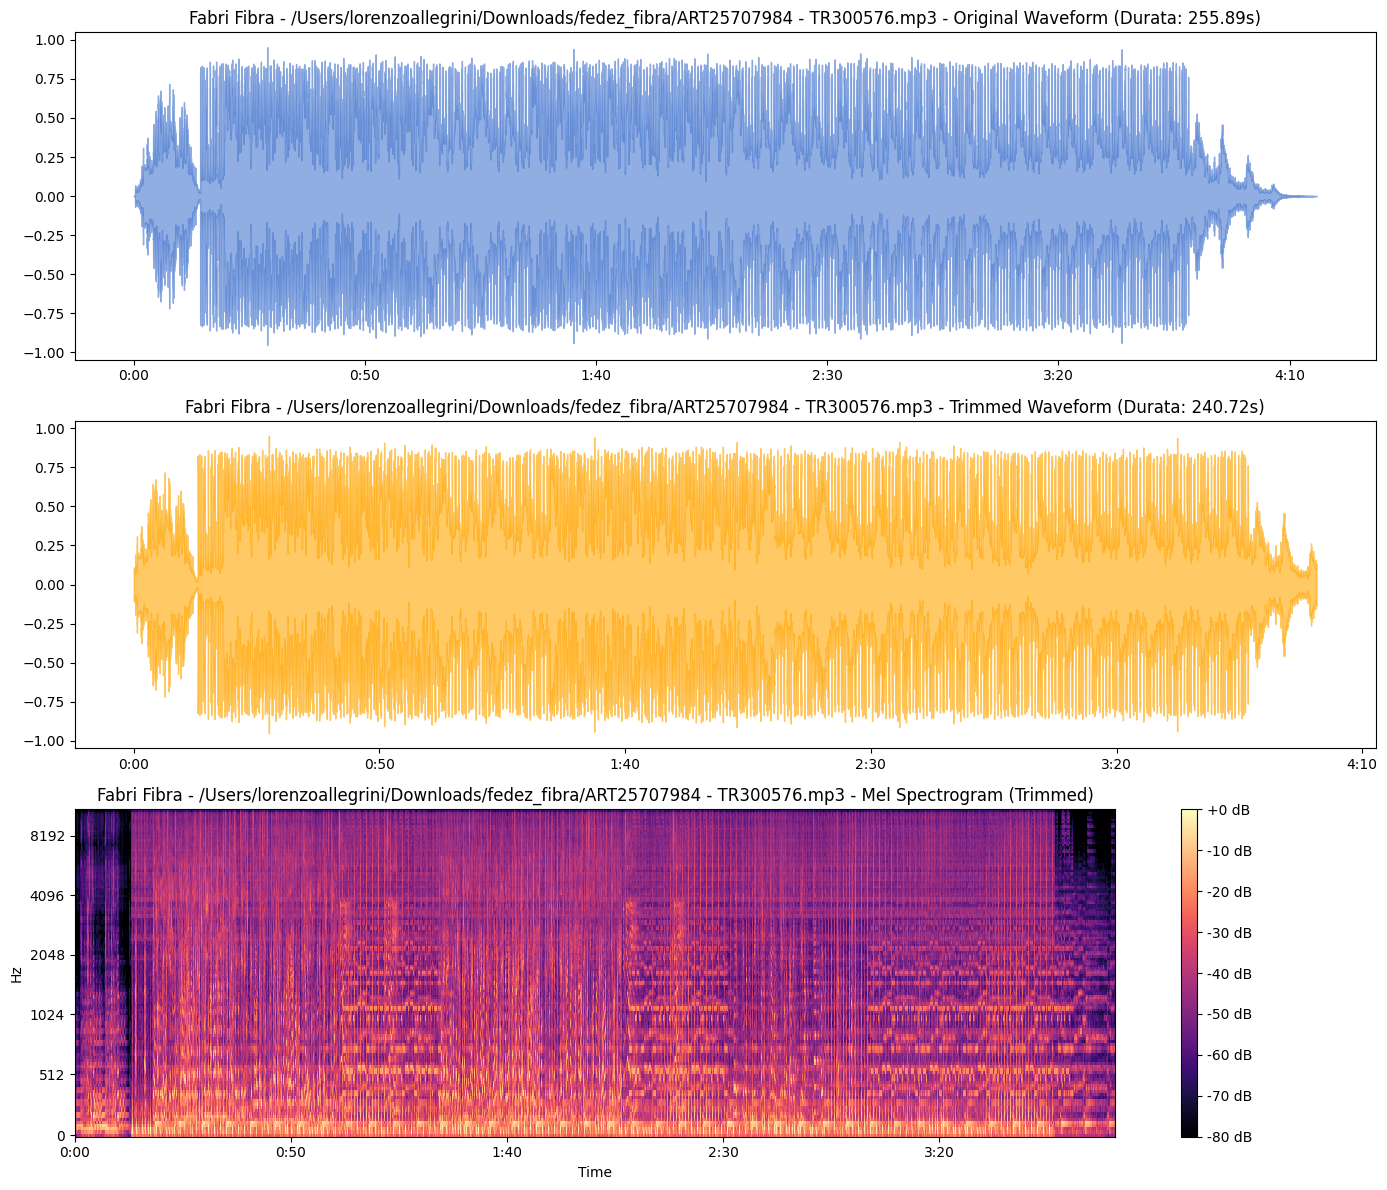

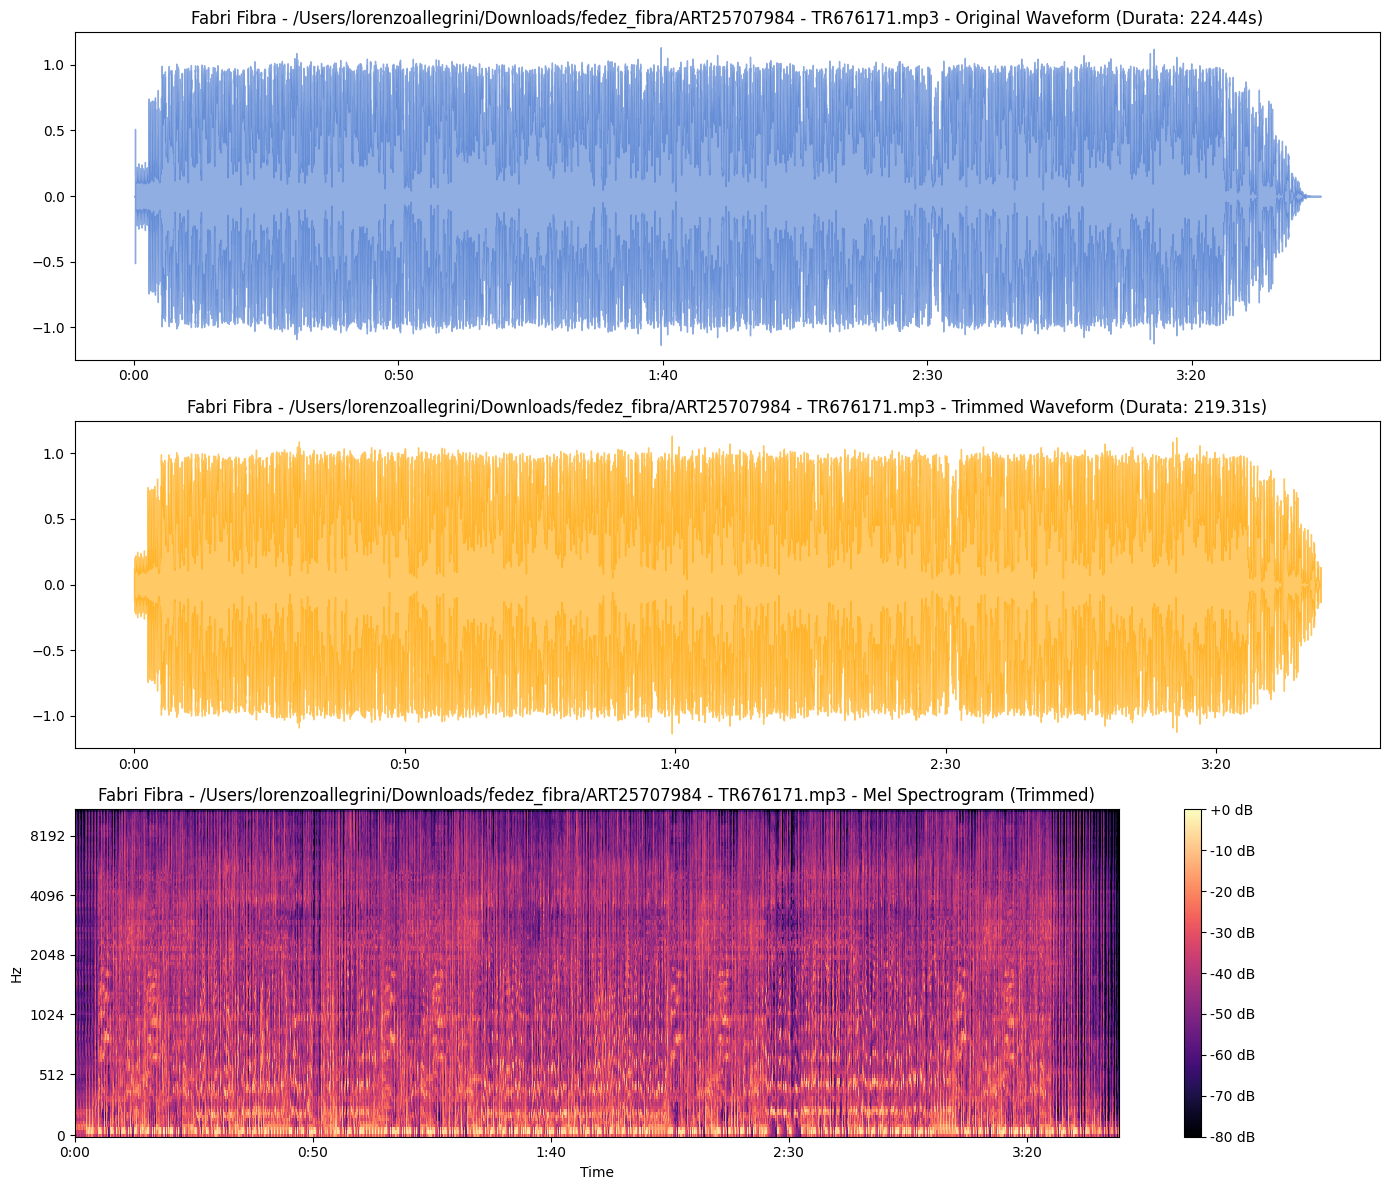

In [91]:
def visualize_audio(file_path, title="Audio Visualization"):
    y, sr = librosa.load(file_path, sr=22050)
    
    y_trimmed, index = librosa.effects.trim(y, top_db=20)
    
    plt.figure(figsize=(14, 12)) 
    
    plt.subplot(3, 1, 1)
    librosa.display.waveshow(y, sr=sr, alpha=0.6)
    plt.title(f"{title} - Original Waveform (Durata: {librosa.get_duration(y=y, sr=sr):.2f}s)")
    plt.xlabel("") # Rimuovo label x per pulizia
    
    plt.subplot(3, 1, 2)
    S = librosa.feature.melspectrogram(y=y_trimmed, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    
    img = librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(img, format='%+2.0f dB')
    plt.title(f"{title} - Mel Spectrogram (Trimmed)")
    
    plt.tight_layout()
    plt.show()

for sample in fedez_files[:1]:
    visualize_audio(os.path.join(MP3_FOLDER, sample), title=f"Fedez - {sample}")

for sample in fibra_files[:1]:
    visualize_audio(os.path.join(MP3_FOLDER, sample), title=f"Fabri Fibra - {sample}")

## Feature extraction

In [ ]:
target_length = 500
resampler = TimeSeriesResampler(sz=target_length)

In [ ]:
mert_extractor = FeatureExtractor(model_ids=["m-a-p/MERT-v1-95M"], sampling_rates=[24000])
all_features = []

for file_path in tqdm(all_files):
    features = mert_extractor.extract_features(
        file_path=file_path,
        cache_dir="../extracted_features"  
    )
    all_features.append(features)

mert_embeddings = resampler.fit_transform(all_features)  # shape: (n_songs, 500, 768)


In [ ]:
wav2vec2_extractor = FeatureExtractor(model_ids=["facebook/wav2vec2-base"], sampling_rates=[16000])
all_features = []

for file_path in tqdm(all_files):
    features = wav2vec2_extractor.extract_features(
        file_path=file_path,
        cache_dir="../extracted_features"  
    )
    all_features.append(features)
    
wav2vec2_embeddings = resampler.fit_transform(all_features)  # shape: (n_songs, 500, 768)

In [ ]:
mert_wav2vec2_extractor = FeatureExtractor()
all_features = []

for file_path in tqdm(all_files):
    features = mert_wav2vec2_extractor.extract_features(
        file_path=file_path,
        cache_dir="../extracted_features"  
    )
    all_features.append(features)

mert_wav2vec2_embeddings = resampler.fit_transform(all_features)  # shape: (n_songs, 500, 768)


## Clustering by global pooling on embeddings with MERT

In [ ]:
global_mert_embedding = mert_embeddings.mean(axis=1)
normalizer = Normalizer()
mert_embeddings_normalized = normalizer.fit_transform(global_mert_embedding)

pca = PCA(n_components=0.9) # keep 90% of the variance
mert_embeddings_pca = pca.fit_transform(mert_embeddings_normalized)

print(f"Reduced to {mert_embeddings_pca.shape[1]} dimensions.")

(454, 768)
Shape originale: (454, 768)
Ridotto a 158 dimensioni (componenti).


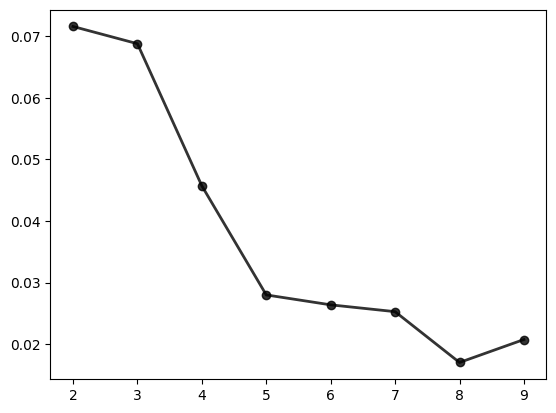

In [ ]:
from sklearn.metrics import silhouette_score

scores = []
k_values = range(2,15)
for i in k_values:
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    predicted_clusters = kmeans.fit_predict(mert_embeddings_pca)
    scores.append(silhouette_score(mert_embeddings_pca, predicted_clusters))

fig, axes = plt.subplots()
plt.plot(k_values, scores, marker='o', color='black', linestyle='-', linewidth=2, alpha=0.8)
plt.show()

use the number of clusters based on the elbow

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
predicted_clusters = kmeans.fit_predict(X_pca)

Clustering completato.


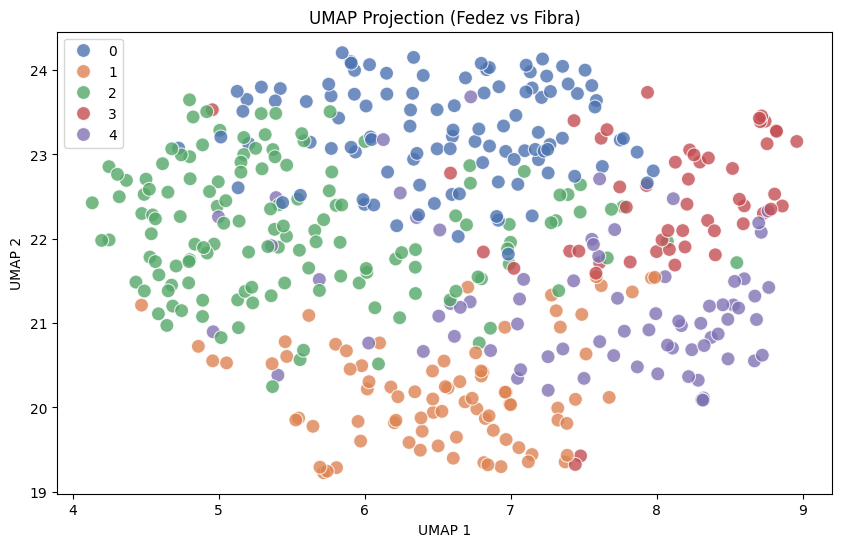

In [ ]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns


reducer = umap.UMAP(
    n_neighbors=30, 
    min_dist=0.1, 
    n_components=2, 
    random_state=42
)

X_umap = reducer.fit_transform(X_pca)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_umap[:, 0], 
    y=X_umap[:, 1], 
    hue=predicted_clusters, 
    palette='colorblind',
    s=100,
    legend='full',
    alpha=0.8 
)
plt.title('UMAP Projection (Fedez vs Fibra)')
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

### Cluster Interpretability

In [ ]:
from transformers import ClapModel, ClapProcessor
model = ClapModel.from_pretrained("laion/clap-htsat-unfused")
processor = ClapProcessor.from_pretrained("laion/clap-htsat-unfused")

rap_styles = [
    "Hardcore Rap",
    "Old School Hip Hop",
    "Boom Bap",
    "Conscious Rap",
    "Storytelling Rap",
    "Aggressive Rap",
    "Double Time Rap",
    "Freestyle Rap",
    "Gangsta Rap",
    
    "Pop Rap",
    "Melodic Rap",
    "Commercial Rap",
    "Party Rap / Club Rap",
    "Autotuned Rap",
    "Italian Pop Rap",
    
    "Trap",
    "Cloud Rap",
    "Emo Rap",
    "Dark Rap",
    "Alternative Hip Hop",
    "Chill / Lo-Fi Rap"
]

structure_labels = [
    "Very repetitive sections",
    "Clear verse-chorus structure",
    "Evolving sections with noticeable changes",
    "Chaotic or fragmented structure",
    "Gradual build-up increasing intensity",
    "Minimal variation, repetitive loops",
    "Choruses differ significantly from verses"
]

density_labels = [
    "Very dense, many overlapping layers",
    "Moderately dense, balanced elements",
    "Sparse, few instruments, lots of space",
    "Alternating sparse and dense sections",
    "Cluttered with overlapping melodic/percussive elements",
    "Very light instrumentation, focus on silence/space"
]

voice_balance_labels = [
    "Vocals clearly dominant",
    "Instrumental dominant with vocals blended",
    "Vocals and instrumental equally balanced",
    "Vocals dominate only in choruses",
    "Vocals blend in the background",
    "Vocals prominent in some passages, minimal in others"
]

tempo_perception_labels = [
    "Fast and urgent",
    "Steady, moderate pacing",
    "Slow or stretched",
    "Variable tempo within sections",
    "Mostly slow with occasional bursts",
    "Irregular or syncopated, hard to perceive steady beat"
]

def clap_classify(labels, y, sr):
    inputs = processor(
        text=labels,
        audio=y,
        return_tensors="pt",
        padding=True,
        sampling_rate=sr
    )
    outputs = model(**inputs)
    probs = outputs.logits_per_audio.softmax(dim=1)
    return probs[0]


In [ ]:
sr = 48000

cluster_prompt_means = []

for cluster_idx, cluster in enumerate(cluster_samples):
    cluster_dict = {}
    
    for name, labels in [
        ("Style", rap_styles),
        ("Structure", structure_labels),
        ("Density", density_labels),
        ("VoiceBalance", voice_balance_labels),
        ("TempoPerception", tempo_perception_labels)
    ]:
        probs_list = []

        
        for song_idx in cluster:
            y, sr = librosa.load(all_files[song_idx], sr=48000)
            probs = clap_classify(labels, y, sr) 
            probs_list.append(probs.detach().cpu().numpy())  

        mean_probs = np.mean(np.stack(probs_list), axis=0)  
        cluster_dict[name] = mean_probs

    cluster_prompt_means.append(cluster_dict)

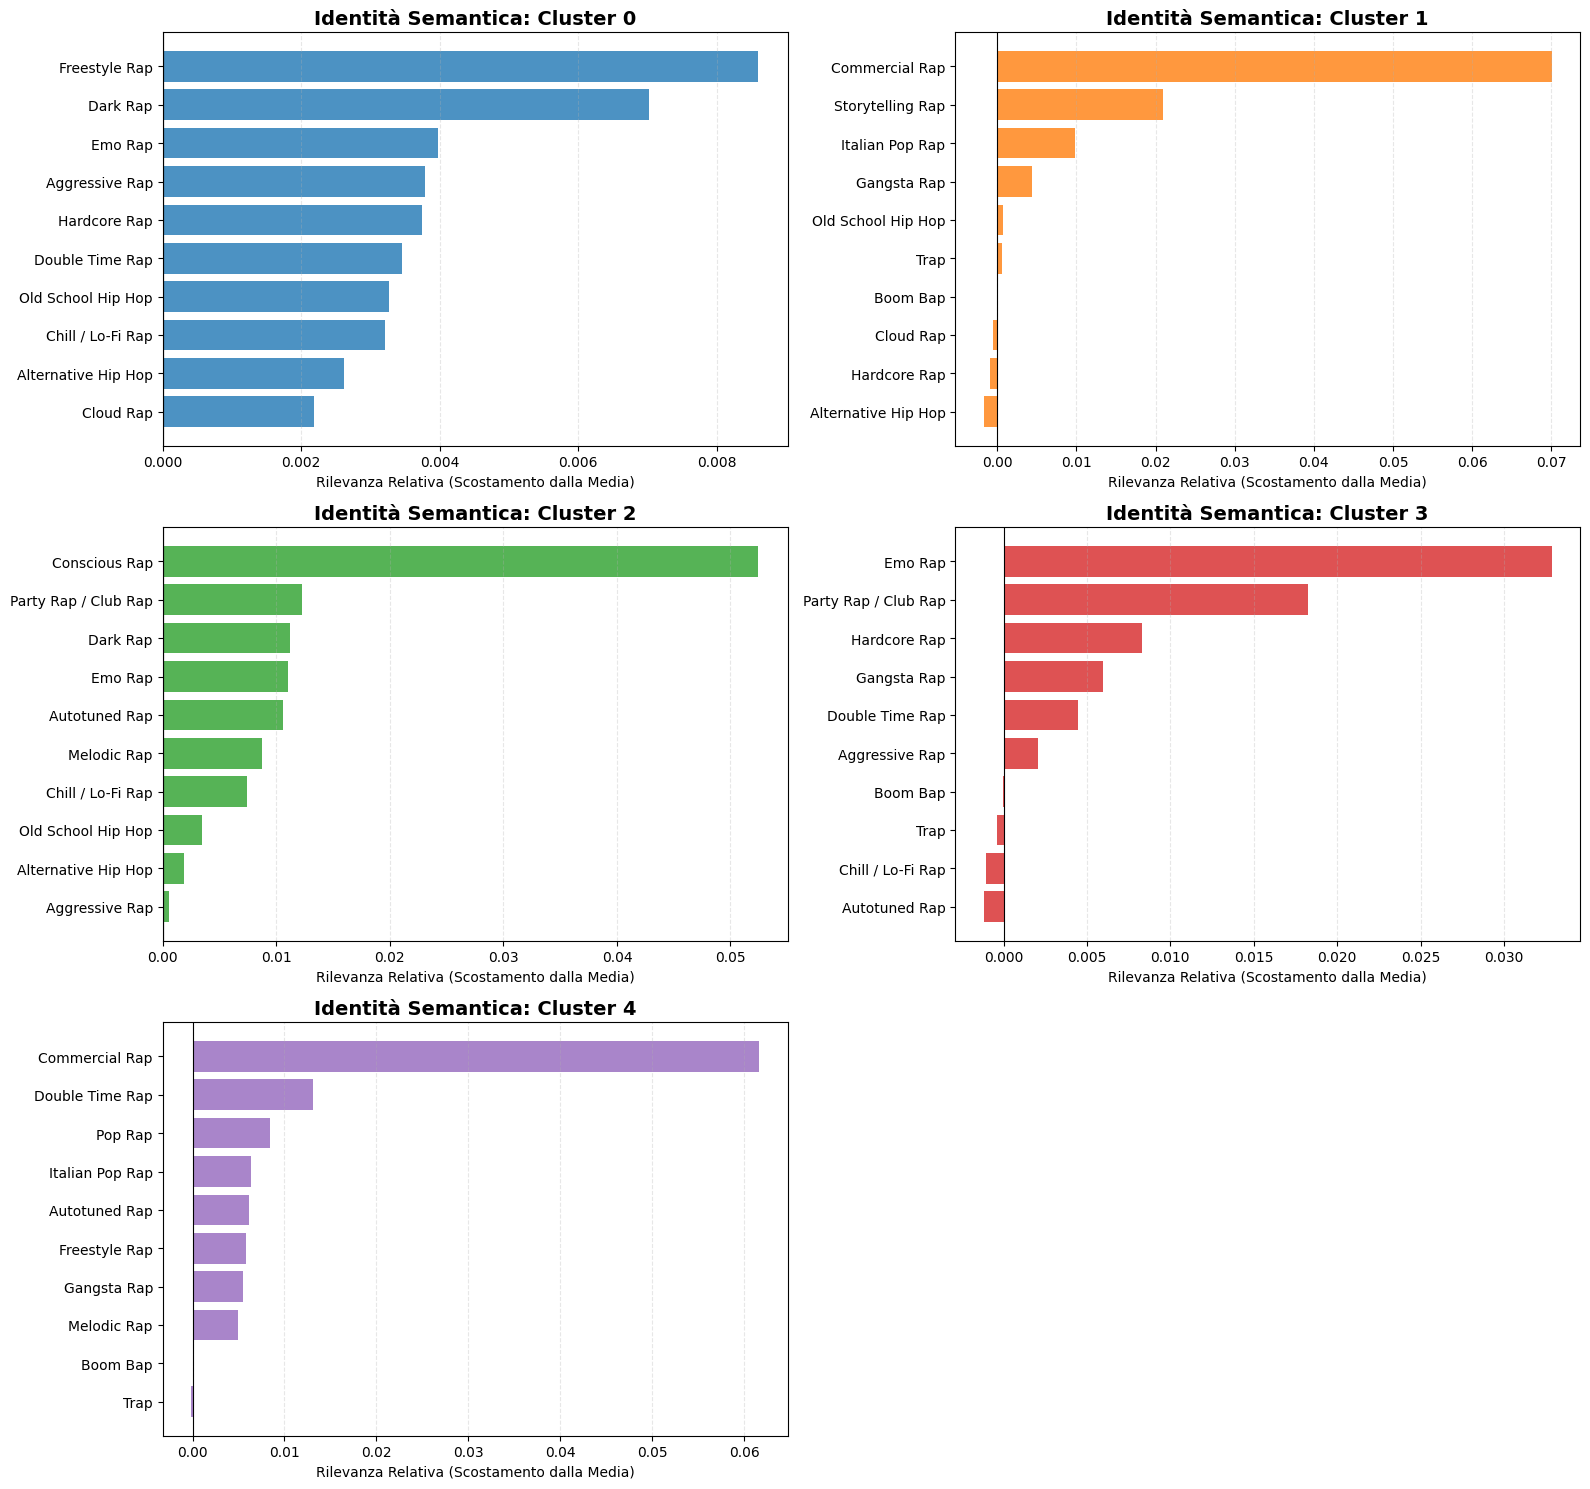

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

all_means = np.array([d["Style"] for d in cluster_prompt_means])
global_style_mean = np.mean(all_means, axis=0)

n_clusters = len(cluster_prompt_means)
cols = 2
rows = (n_clusters + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
axes = axes.flatten()
cmap = plt.get_cmap('tab10') 

for i in range(n_clusters):
    ax = axes[i]
    
    relevance = cluster_prompt_means[i]["Style"] - global_style_mean
    
    top_indices = np.argsort(relevance)[-10:]
    top_labels = [rap_styles[idx] for idx in top_indices]
    top_values = relevance[top_indices]
    
    color = cmap(i % 10)
    ax.barh(top_labels, top_values, color=color, alpha=0.8)
    
    ax.set_title(f"Semantic Identity: Cluster {i}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Relative Relevance (Deviation from Mean)")
    ax.axvline(0, color='black', linewidth=0.8)
    ax.grid(axis='x', linestyle='--', alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

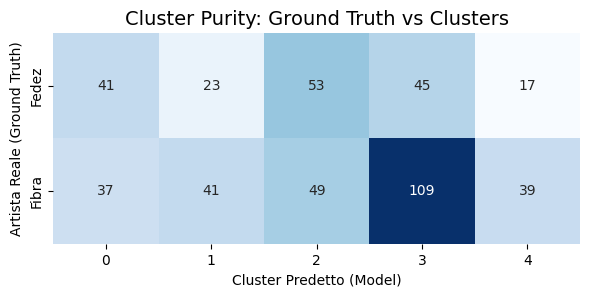

Cluster Predetto (Model),0,1,2,3,4
Artista Reale (Ground Truth),,,,,
Fedez,41,23,53,45,17
Fibra,37,41,49,109,39


In [ ]:
true_labels = ["Fedez" if f in fedez_files else "Fibra" for f in all_files]
plot_cluster_purity(true_labels, predicted_clusters)

## Clustering by global pooling on embeddings with Wav2Vec2-base

In [ ]:
X_global = X_resampled.std(axis=1)
print(X_global.shape)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import Normalizer
import numpy as np

print(f"Shape originale: {X_global.shape}")

normalizer = Normalizer()
X_norm = normalizer.fit_transform(X_global)

pca = PCA(n_components=0.9) # Tieni il 95% della varianza
X_pca = pca.fit_transform(X_norm)

print(f"Ridotto a {X_pca.shape[1]} dimensioni (componenti).")

(454, 768)
Shape originale: (454, 768)
Ridotto a 90 dimensioni (componenti).


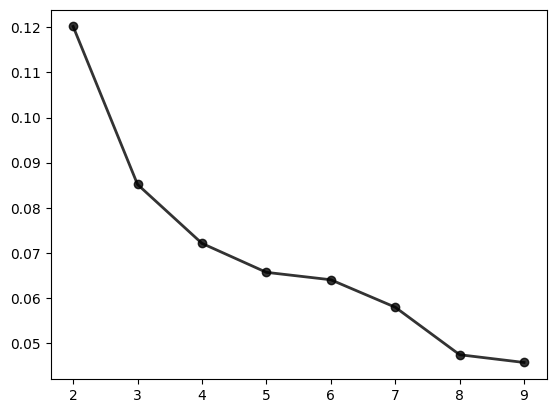

In [ ]:
from sklearn.metrics import silhouette_score, adjusted_rand_score, classification_report, confusion_matrix

scores = []
k_values = range(2,10)
for i in k_values:
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    predicted_clusters = kmeans.fit_predict(X_pca)
    scores.append(silhouette_score(X_pca, predicted_clusters))


fig, axes = plt.subplots()
plt.plot(k_values, scores, marker='o', color='black', linestyle='-', linewidth=2, alpha=0.8)
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
predicted_clusters = kmeans.fit_predict(X_pca)

print("Clustering completato.")

Clustering completato.


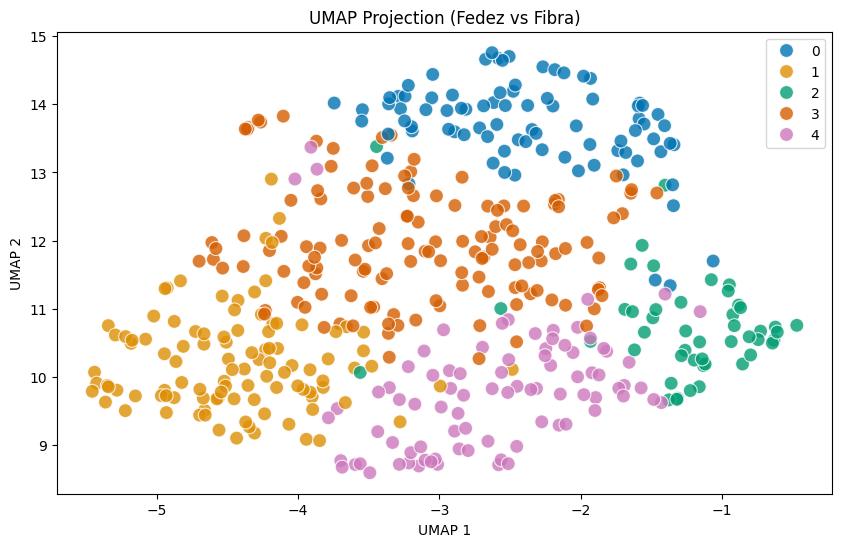

In [ ]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns


reducer = umap.UMAP(
    n_neighbors=30,   
    min_dist=0.1, 
    n_components=2, 
    random_state=42
)

X_umap = reducer.fit_transform(X_pca)

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_umap[:, 0], 
    y=X_umap[:, 1], 
    hue=predicted_clusters, 
    palette='colorblind',
    s=100,
    legend='full',
    alpha=0.8 # Aggiungo trasparenza per vedere le sovrapposizioni
)
plt.title('UMAP Projection (Fedez vs Fibra)')
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

### Cluster Interpretability

In [ ]:
from transformers import ClapModel, ClapProcessor
model = ClapModel.from_pretrained("laion/clap-htsat-unfused")
processor = ClapProcessor.from_pretrained("laion/clap-htsat-unfused")

rap_styles = [
    "Hardcore Rap",
    "Old School Hip Hop",
    "Boom Bap",
    "Conscious Rap",
    "Storytelling Rap",
    "Aggressive Rap",
    "Double Time Rap",
    "Freestyle Rap",
    "Gangsta Rap",
    
    "Pop Rap",
    "Melodic Rap",
    "Commercial Rap",
    "Party Rap / Club Rap",
    "Autotuned Rap",
    "Italian Pop Rap",
    
    "Trap",
    "Cloud Rap",
    "Emo Rap",
    "Dark Rap",
    "Alternative Hip Hop",
    "Chill / Lo-Fi Rap"
]

structure_labels = [
    "Very repetitive sections",
    "Clear verse-chorus structure",
    "Evolving sections with noticeable changes",
    "Chaotic or fragmented structure",
    "Gradual build-up increasing intensity",
    "Minimal variation, repetitive loops",
    "Choruses differ significantly from verses"
]

density_labels = [
    "Very dense, many overlapping layers",
    "Moderately dense, balanced elements",
    "Sparse, few instruments, lots of space",
    "Alternating sparse and dense sections",
    "Cluttered with overlapping melodic/percussive elements",
    "Very light instrumentation, focus on silence/space"
]

voice_balance_labels = [
    "Vocals clearly dominant",
    "Instrumental dominant with vocals blended",
    "Vocals and instrumental equally balanced",
    "Vocals dominate only in choruses",
    "Vocals blend in the background",
    "Vocals prominent in some passages, minimal in others"
]

tempo_perception_labels = [
    "Fast and urgent",
    "Steady, moderate pacing",
    "Slow or stretched",
    "Variable tempo within sections",
    "Mostly slow with occasional bursts",
    "Irregular or syncopated, hard to perceive steady beat"
]

def clap_classify(labels, y, sr):
    inputs = processor(
        text=labels,
        audio=y,
        return_tensors="pt",
        padding=True,
        sampling_rate=sr
    )
    outputs = model(**inputs)
    probs = outputs.logits_per_audio.softmax(dim=1)
    return probs[0]


In [ ]:
sr = 48000

cluster_prompt_means = []

for cluster_idx, cluster in enumerate(cluster_samples):
    cluster_dict = {}
    
    for name, labels in [
        ("Style", rap_styles),
        ("Structure", structure_labels),
        ("Density", density_labels),
        ("VoiceBalance", voice_balance_labels),
        ("TempoPerception", tempo_perception_labels)
    ]:
        probs_list = []

        
        for song_idx in cluster:
            y, sr = librosa.load(all_files[song_idx], sr=48000)
            probs = clap_classify(labels, y, sr) 
            probs_list.append(probs.detach().cpu().numpy())  

        mean_probs = np.mean(np.stack(probs_list), axis=0)  
        cluster_dict[name] = mean_probs

    cluster_prompt_means.append(cluster_dict)

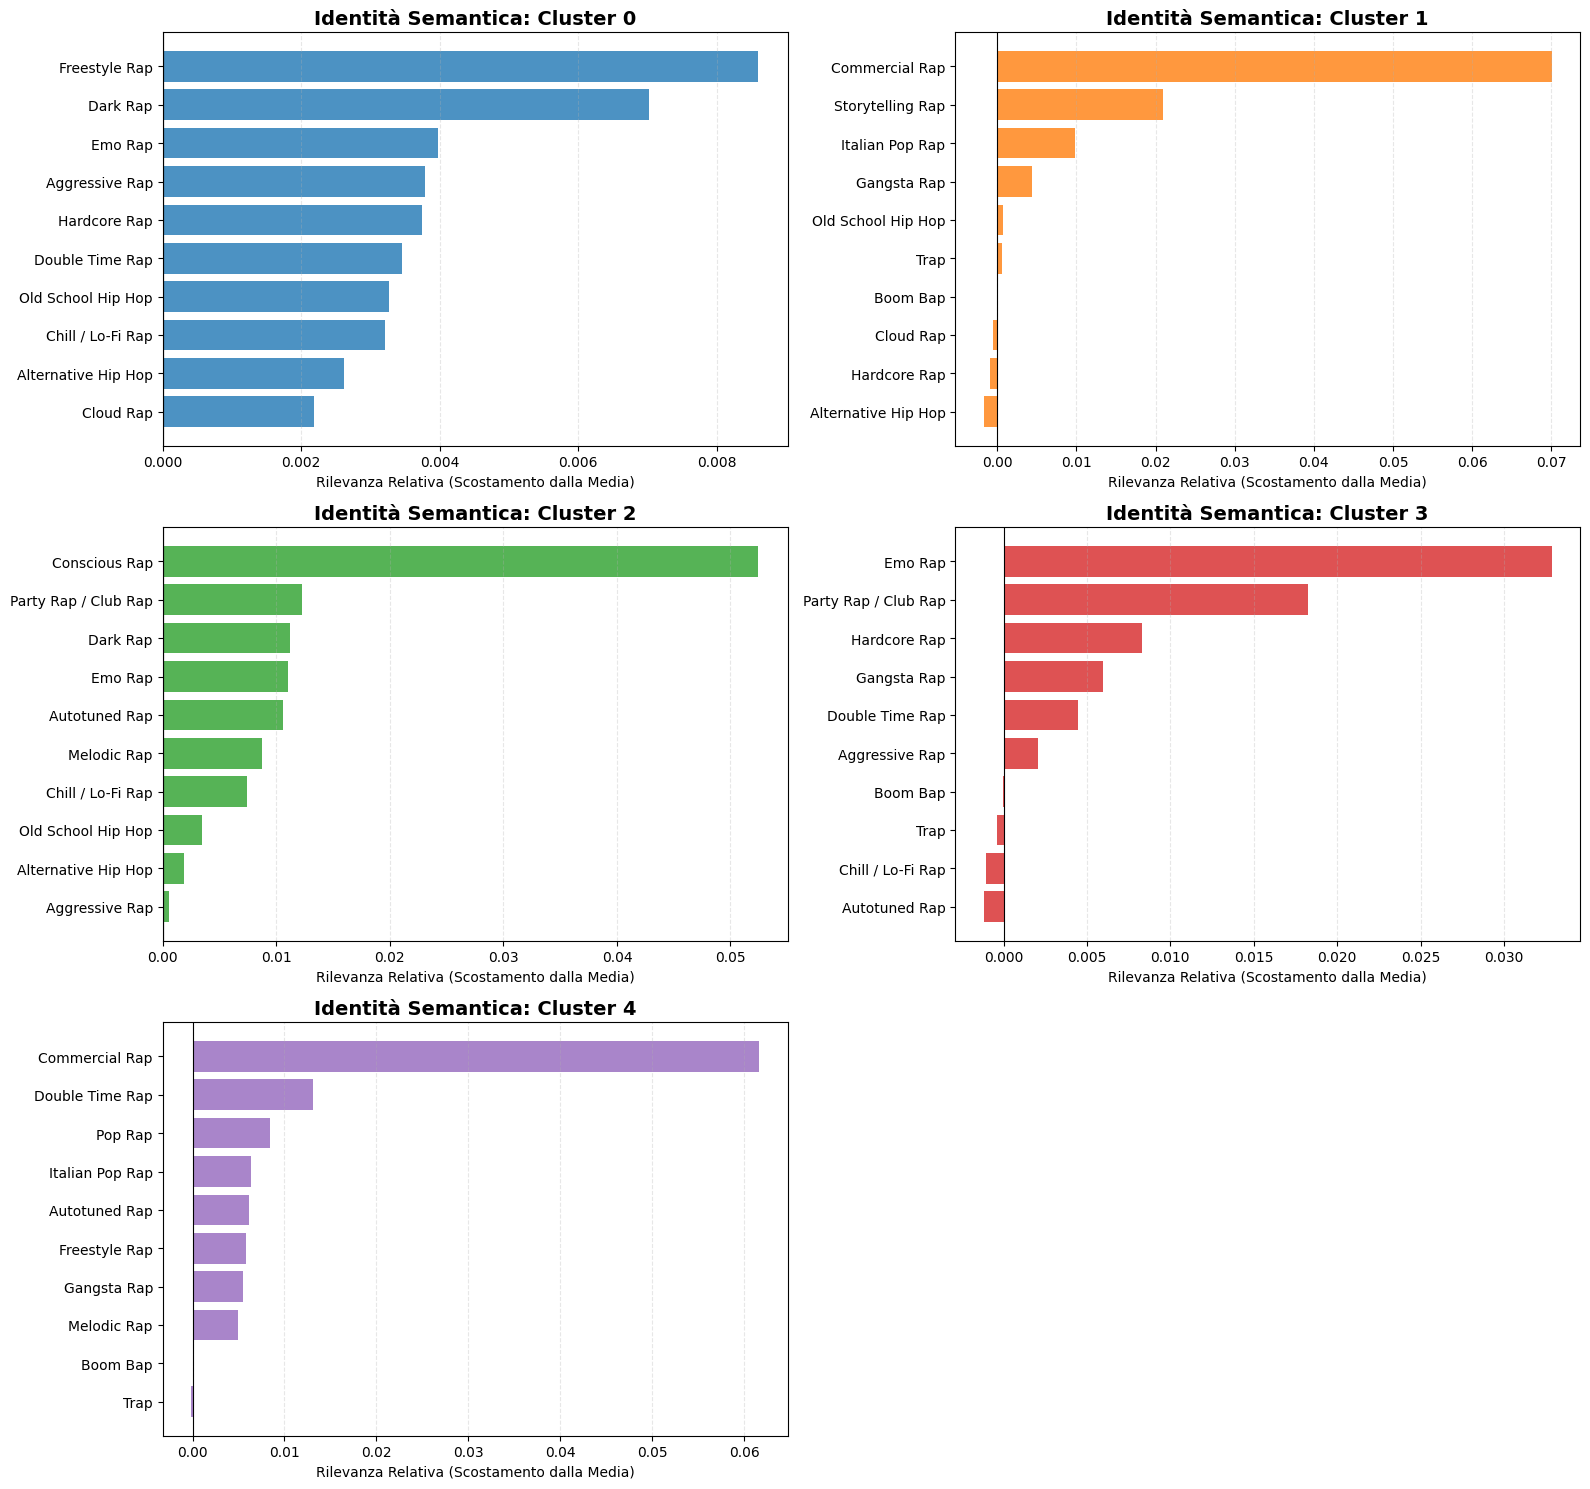

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

all_means = np.array([d["Style"] for d in cluster_prompt_means])
global_style_mean = np.mean(all_means, axis=0)

n_clusters = len(cluster_prompt_means)
cols = 2
rows = (n_clusters + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
axes = axes.flatten()
cmap = plt.get_cmap('tab10') 

for i in range(n_clusters):
    ax = axes[i]
    
    relevance = cluster_prompt_means[i]["Style"] - global_style_mean
    
    top_indices = np.argsort(relevance)[-10:]
    top_labels = [rap_styles[idx] for idx in top_indices]
    top_values = relevance[top_indices]
    
    color = cmap(i % 10)
    ax.barh(top_labels, top_values, color=color, alpha=0.8)
    
    ax.set_title(f"Semantic Identity: Cluster {i}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Relative Relevance (Deviation from Mean)")
    ax.axvline(0, color='black', linewidth=0.8)
    ax.grid(axis='x', linestyle='--', alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

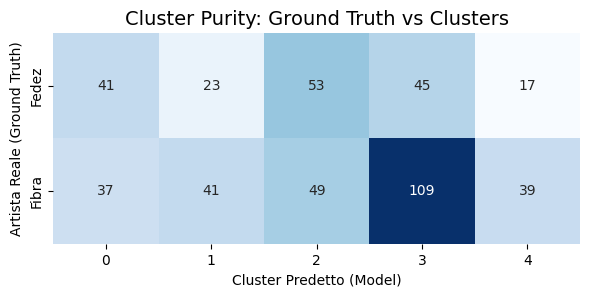

Cluster Predetto (Model),0,1,2,3,4
Artista Reale (Ground Truth),,,,,
Fedez,41,23,53,45,17
Fibra,37,41,49,109,39


In [ ]:
true_labels = ["Fedez" if f in fedez_files else "Fibra" for f in all_files]
plot_cluster_purity(true_labels, predicted_clusters)

## Clustering by mean pooling of embeddings with both MERT and Wav2Vec2

In [ ]:
X_global = X_resampled.std(axis=1)
print(X_global.shape)

print(f"Shape originale: {X_global.shape}")

normalizer = Normalizer()
X_norm = normalizer.fit_transform(X_global)

pca = PCA(n_components=0.9) # Tieni il 95% della varianza
X_pca = pca.fit_transform(X_norm)

print(f"Ridotto a {X_pca.shape[1]} dimensioni (componenti).")

(454, 1536)
Shape originale: (454, 1536)
Ridotto a 156 dimensioni (componenti).


### finding best k

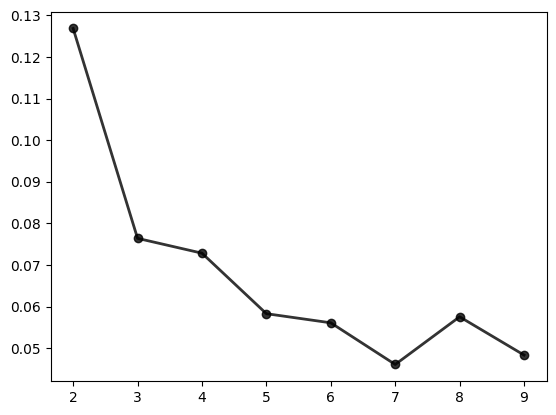

In [245]:
from sklearn.metrics import silhouette_score, adjusted_rand_score, classification_report, confusion_matrix

scores = []
k_values = range(2,10)
for i in k_values:
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    predicted_clusters = kmeans.fit_predict(X_pca)
    scores.append(silhouette_score(X_pca, predicted_clusters))


fig, axes = plt.subplots()
plt.plot(k_values, scores, marker='o', color='black', linestyle='-', linewidth=2, alpha=0.8)
plt.show()

In [246]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
predicted_clusters = kmeans.fit_predict(X_pca)

Clustering completato.


### k means plotting with 2d umap reduction

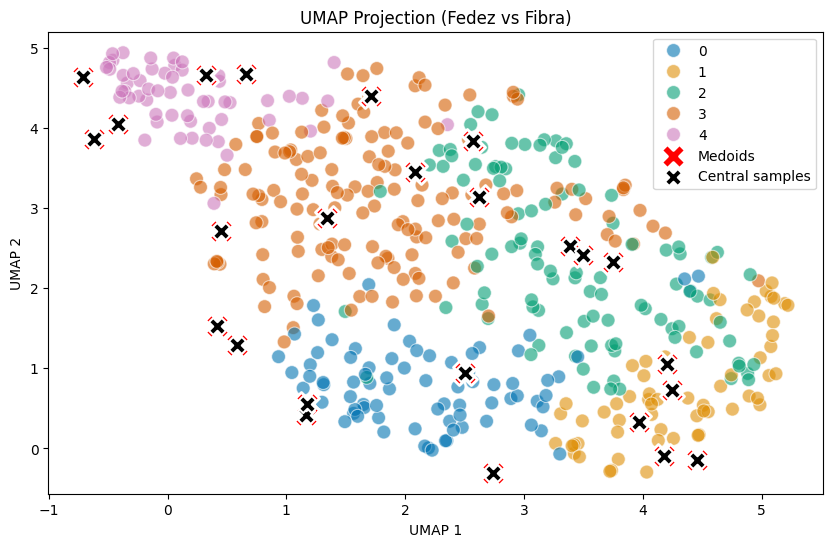

In [ ]:
reducer = umap.UMAP(
    n_neighbors=30,  
    min_dist=0.1, 
    n_components=2, 
    random_state=42
)

X_umap = reducer.fit_transform(X_pca)

unique_clusters = np.unique(predicted_clusters)

cluster_samples = []
samples_per_cluster = 5

for c in unique_clusters:
    idx_cluster = np.where(predicted_clusters == c)[0]  # indici globali
    X_c = X_pca[idx_cluster]

    centroid = X_c.mean(axis=0)
    dist_to_centroid = np.linalg.norm(X_c - centroid, axis=1)

    closest_idx_local = np.argsort(dist_to_centroid)[:samples_per_cluster]
    closest_idx_global = idx_cluster[closest_idx_local]

    cluster_samples.append(closest_idx_global)

central_samples_indices = np.concatenate(cluster_samples)
central_samples = X_pca[central_samples_indices]
central_samples_umap = reducer.transform(central_samples)


plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=X_umap[:, 0], 
    y=X_umap[:, 1], 
    hue=predicted_clusters, 
    palette='colorblind',
    s=100,
    legend='full',
    alpha=0.6
)


plt.title('UMAP Projection (Fedez vs Fibra)')
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.show()


### Cluster Interpretability

In [ ]:
from transformers import ClapModel, ClapProcessor
model = ClapModel.from_pretrained("laion/clap-htsat-unfused")
processor = ClapProcessor.from_pretrained("laion/clap-htsat-unfused")

rap_styles = [
    "Hardcore Rap",
    "Old School Hip Hop",
    "Boom Bap",
    "Conscious Rap",
    "Storytelling Rap",
    "Aggressive Rap",
    "Double Time Rap",
    "Freestyle Rap",
    "Gangsta Rap",
    
    "Pop Rap",
    "Melodic Rap",
    "Commercial Rap",
    "Party Rap / Club Rap",
    "Autotuned Rap",
    "Italian Pop Rap",
    
    "Trap",
    "Cloud Rap",
    "Emo Rap",
    "Dark Rap",
    "Alternative Hip Hop",
    "Chill / Lo-Fi Rap"
]

structure_labels = [
    "Very repetitive sections",
    "Clear verse-chorus structure",
    "Evolving sections with noticeable changes",
    "Chaotic or fragmented structure",
    "Gradual build-up increasing intensity",
    "Minimal variation, repetitive loops",
    "Choruses differ significantly from verses"
]

density_labels = [
    "Very dense, many overlapping layers",
    "Moderately dense, balanced elements",
    "Sparse, few instruments, lots of space",
    "Alternating sparse and dense sections",
    "Cluttered with overlapping melodic/percussive elements",
    "Very light instrumentation, focus on silence/space"
]

voice_balance_labels = [
    "Vocals clearly dominant",
    "Instrumental dominant with vocals blended",
    "Vocals and instrumental equally balanced",
    "Vocals dominate only in choruses",
    "Vocals blend in the background",
    "Vocals prominent in some passages, minimal in others"
]

tempo_perception_labels = [
    "Fast and urgent",
    "Steady, moderate pacing",
    "Slow or stretched",
    "Variable tempo within sections",
    "Mostly slow with occasional bursts",
    "Irregular or syncopated, hard to perceive steady beat"
]

def clap_classify(labels, y, sr):
    inputs = processor(
        text=labels,
        audio=y,
        return_tensors="pt",
        padding=True,
        sampling_rate=sr
    )
    outputs = model(**inputs)
    probs = outputs.logits_per_audio.softmax(dim=1)
    return probs[0]


In [ ]:
sr = 48000

cluster_prompt_means = []

for cluster_idx, cluster in enumerate(cluster_samples):
    cluster_dict = {}
    
    for name, labels in [
        ("Style", rap_styles),
        ("Structure", structure_labels),
        ("Density", density_labels),
        ("VoiceBalance", voice_balance_labels),
        ("TempoPerception", tempo_perception_labels)
    ]:
        probs_list = []

        
        for song_idx in cluster:
            y, sr = librosa.load(all_files[song_idx], sr=48000)
            probs = clap_classify(labels, y, sr) 
            probs_list.append(probs.detach().cpu().numpy())  

        mean_probs = np.mean(np.stack(probs_list), axis=0)  
        cluster_dict[name] = mean_probs

    cluster_prompt_means.append(cluster_dict)

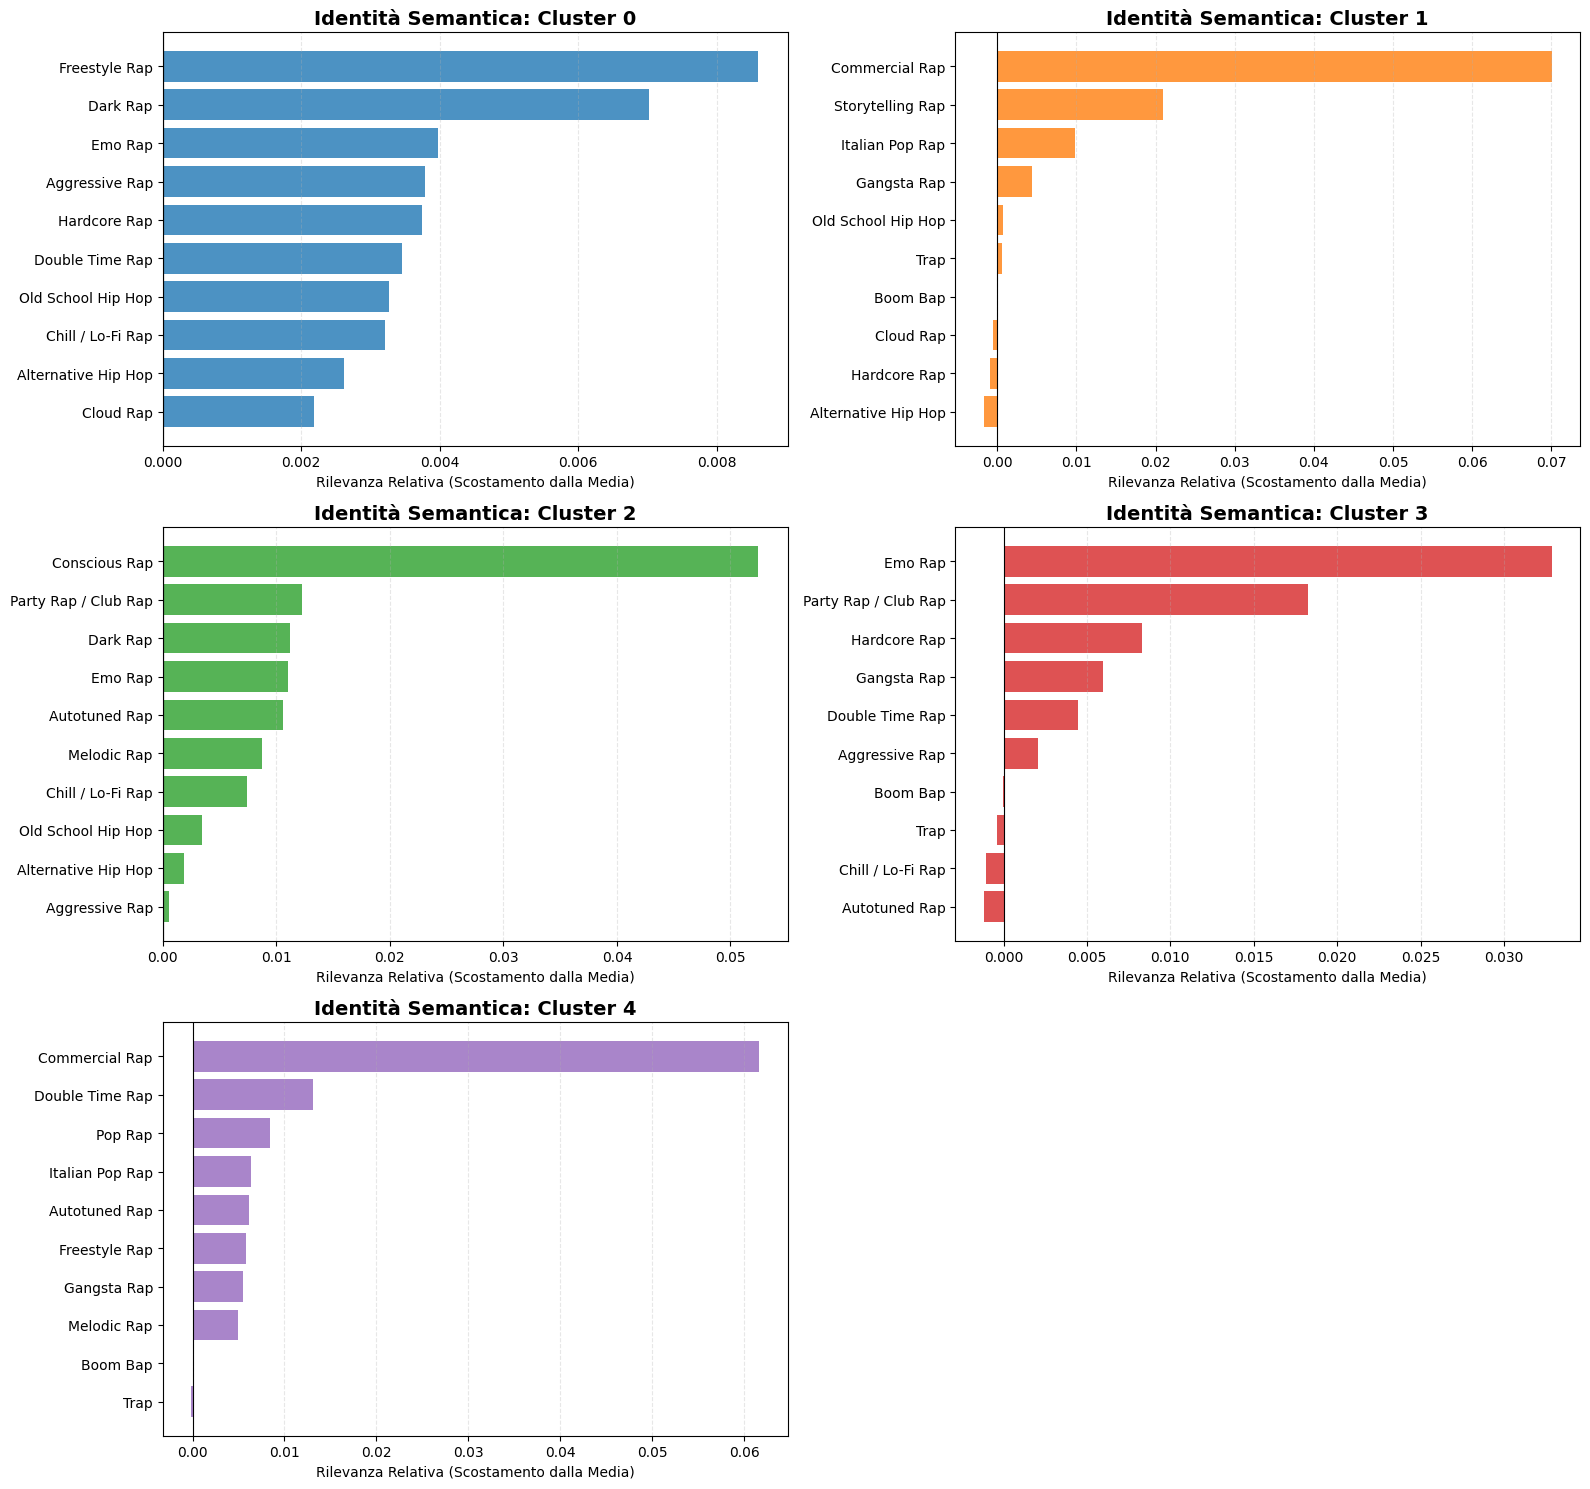

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

all_means = np.array([d["Style"] for d in cluster_prompt_means])
global_style_mean = np.mean(all_means, axis=0)

n_clusters = len(cluster_prompt_means)
cols = 2
rows = (n_clusters + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
axes = axes.flatten()
cmap = plt.get_cmap('tab10') 

for i in range(n_clusters):
    ax = axes[i]
    
    relevance = cluster_prompt_means[i]["Style"] - global_style_mean
    
    top_indices = np.argsort(relevance)[-10:]
    top_labels = [rap_styles[idx] for idx in top_indices]
    top_values = relevance[top_indices]
    
    color = cmap(i % 10)
    ax.barh(top_labels, top_values, color=color, alpha=0.8)
    
    ax.set_title(f"Semantic Identity: Cluster {i}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Relative Relevance (Deviation from Mean)")
    ax.axvline(0, color='black', linewidth=0.8)
    ax.grid(axis='x', linestyle='--', alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

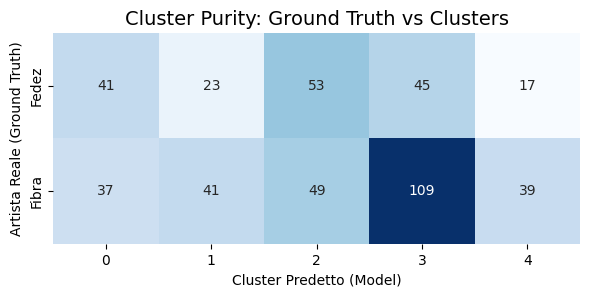

Cluster Predetto (Model),0,1,2,3,4
Artista Reale (Ground Truth),,,,,
Fedez,41,23,53,45,17
Fibra,37,41,49,109,39


In [267]:
true_labels = ["Fedez" if f in fedez_files else "Fibra" for f in all_files]
plot_cluster_purity(true_labels, predicted_clusters)

## Clustering by DTW

In [268]:
# Preparazione per PCA (Flattening)
n_songs, n_time, n_feat = X_resampled.shape
X_flat = X_resampled.reshape(n_songs * n_time, n_feat)

# PCA
pca = PCA(n_components=3)
mask = ~np.isnan(X_flat).any(axis=1)

X_valid = X_flat[mask]
X_pca_valid = pca.fit_transform(X_valid)

X_pca_full = np.full((X_flat.shape[0], pca.n_components), np.nan)
X_pca_full[mask] = X_pca_valid

# Reshape e Scaling
X_pca = X_pca_full.reshape(n_songs, n_time, -1)
scaler = TimeSeriesScalerMeanVariance()
X_scaled = scaler.fit_transform(X_pca)
X_scaled = np.nan_to_num(X_scaled) 

scores = []
k_values = range(2, 10)

print("Inizio ricerca K ottimale...")

for k in tqdm(k_values):
    kmeans = TimeSeriesKMeans(
        n_clusters=k,
        metric="dtw",
        max_iter=10,    
        n_init=3,       # 3 è sufficiente per l'elbow, risparmi tempo
        verbose=False,
        random_state=42,
        n_jobs=-1       # Usa tutti i core della CPU se possibile
    )
    
    # Basta un solo fit!
    kmeans.fit(X_scaled)
    
    # Salviamo l'inerzia
    scores.append(kmeans.inertia_)

# --- Plotting ---
plt.figure(figsize=(10, 6))

# Plot corretto: X=k_values, Y=scores
plt.plot(k_values, scores, marker='o', color='black', linestyle='-', linewidth=2, alpha=0.8)

plt.title("Elbow Method: Inertia vs Number of Clusters (k)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (DTW Distance)")
plt.grid(True, alpha=0.3)
plt.xticks(k_values) # Forza a mostrare tutti i numeri interi sull'asse X

plt.show()

Inizio ricerca K ottimale...


  0%|          | 0/8 [04:14<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
# Preparazione per PCA (Flattening)
n_songs, n_time, n_feat = X_resampled.shape
X_flat = X_resampled.reshape(n_songs * n_time, n_feat)

# PCA
pca = PCA(n_components=0.8, svd_solver='full')
mask = ~np.isnan(X_flat).any(axis=1)

X_valid = X_flat[mask]
X_pca_valid = pca.fit_transform(X_valid)

X_pca_full = np.full((X_flat.shape[0], pca.n_components), np.nan)
X_pca_full[mask] = X_pca_valid

# Reshape e Scaling
X_pca = X_pca_full.reshape(n_songs, n_time, -1)
scaler = TimeSeriesScalerMeanVariance()
X_scaled = scaler.fit_transform(X_pca)

# Clustering
kmeans = TimeSeriesKMeans(
    n_clusters=2,
    metric="dtw",
    max_iter=10,
    n_init=3,
    verbose=True,
    random_state=42
)
predicted_clusters = kmeans.fit_predict(X_scaled)

TypeError: 'float' object cannot be interpreted as an integer

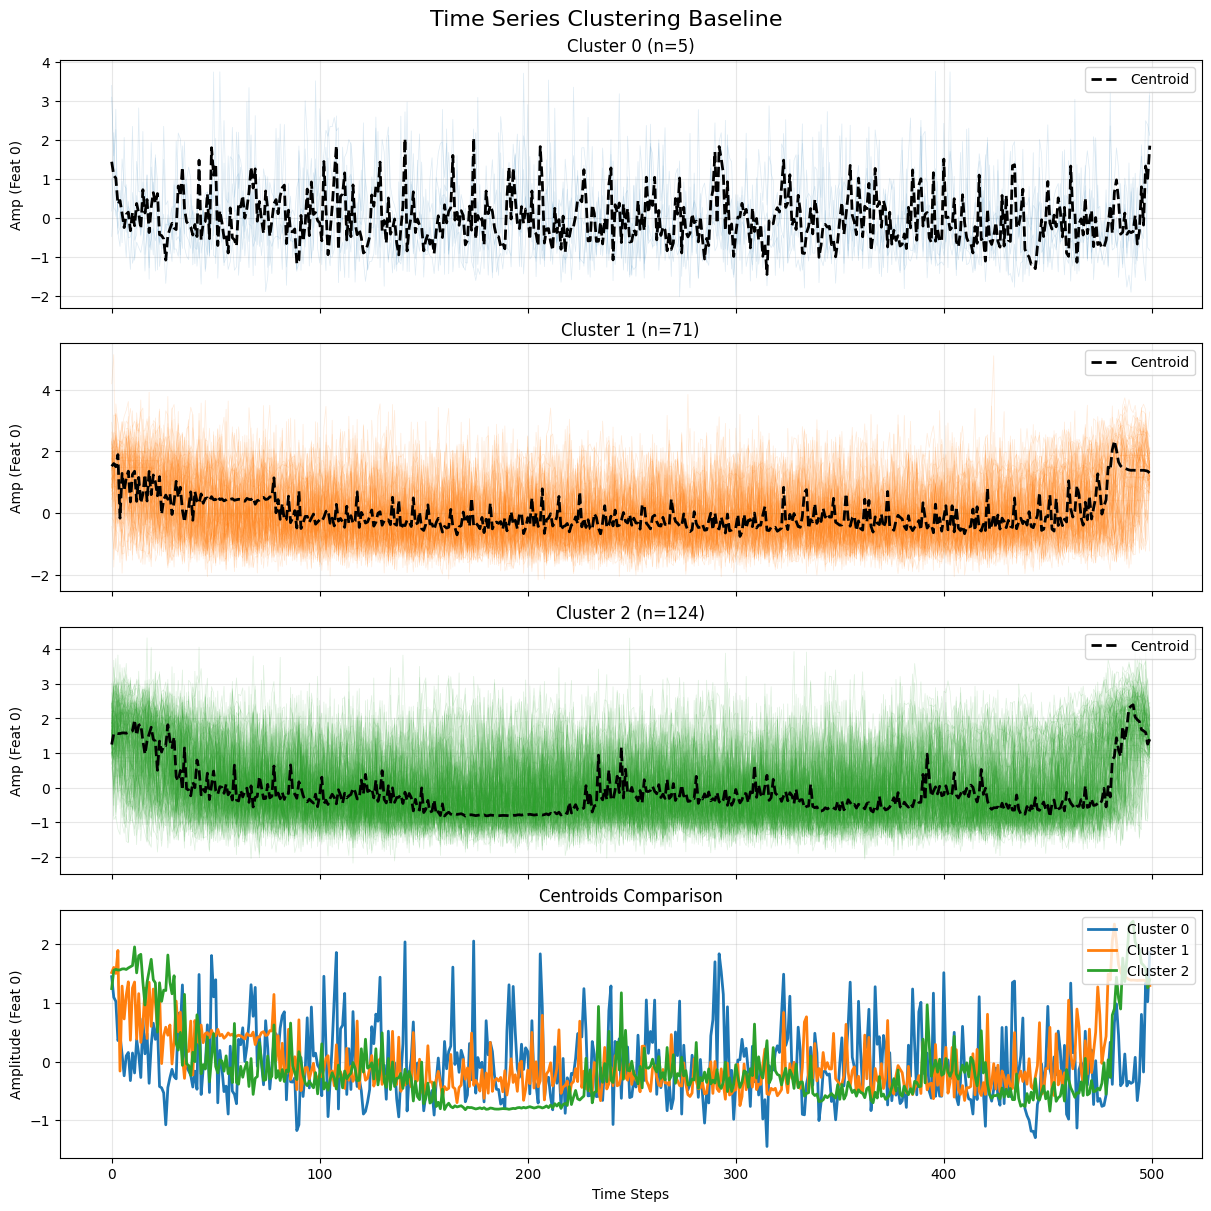

In [ ]:
plot_timeseries_clusters(X_scaled, predicted_clusters, centroids=kmeans.cluster_centers_, feature_idx=0, title="Time Series Clustering Baseline")

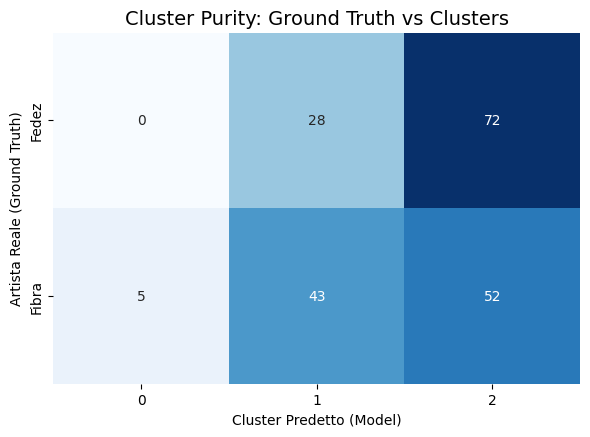

Cluster Predetto (Model),0,1,2
Artista Reale (Ground Truth),,,
Fedez,0,28,72
Fibra,5,43,52


In [ ]:
true_labels = ["Fedez" if f in fedez_files else "Fibra" for f in all_files]
plot_cluster_purity(true_labels, predicted_clusters)

In [269]:

extractor = FeatureExtractor(model_ids=["m-a-p/MERT-v1-95M"], sampling_rates=[24000])
all_features = []

for file_path in tqdm(all_files):
    features = extractor.extract_features(
        file_path=file_path,
        cache_dir="../extracted_features"  
    )
    all_features.append(features)

# Resampling
target_length = 500
resampler = TimeSeriesResampler(sz=target_length)
X_resampled = resampler.fit_transform(all_features)  # shape: (n_songs, 500, 768)


100%|██████████| 454/454 [00:20<00:00, 21.95it/s]


In [270]:
X_global = X_resampled.std(axis=1)
print(X_global.shape)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import Normalizer
import numpy as np

print(f"Shape originale: {X_global.shape}")

normalizer = Normalizer()
X_norm = normalizer.fit_transform(X_global)

pca = PCA(n_components=0.9) # Tieni il 95% della varianza
X_pca = pca.fit_transform(X_norm)

print(f"Ridotto a {X_pca.shape[1]} dimensioni (componenti).")

(454, 768)
Shape originale: (454, 768)
Ridotto a 158 dimensioni (componenti).


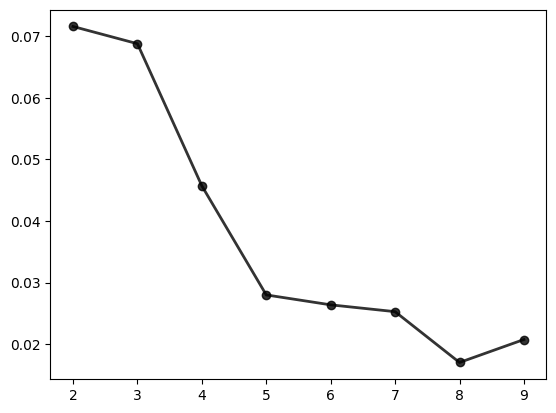

In [271]:
from sklearn.metrics import silhouette_score, adjusted_rand_score, classification_report, confusion_matrix

scores = []
k_values = range(2,10)
for i in k_values:
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    predicted_clusters = kmeans.fit_predict(X_pca)
    scores.append(silhouette_score(X_pca, predicted_clusters))


fig, axes = plt.subplots()
plt.plot(k_values, scores, marker='o', color='black', linestyle='-', linewidth=2, alpha=0.8)
plt.show()

In [272]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
predicted_clusters = kmeans.fit_predict(X_pca)

print("Clustering completato.")

Clustering completato.


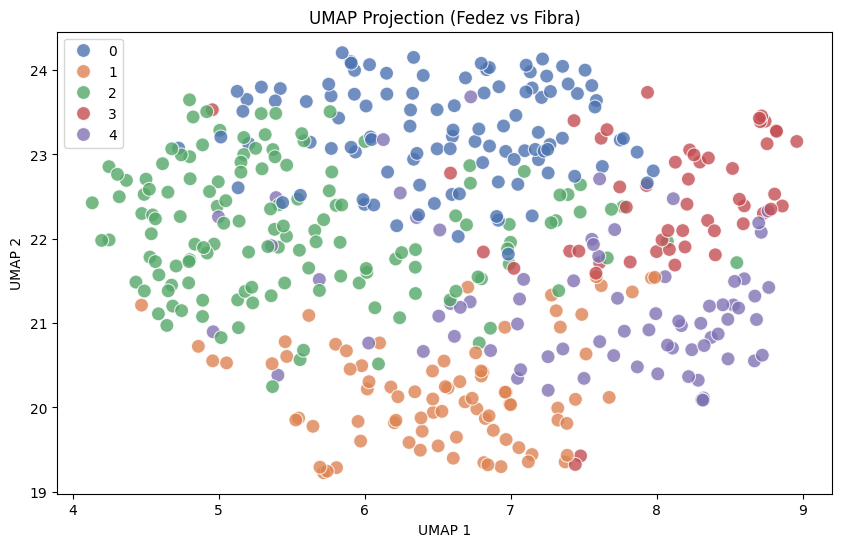

In [273]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns


reducer = umap.UMAP(
    n_neighbors=30,   # Provo 30 per avere una visione più "strutturale"
    min_dist=0.1, 
    n_components=2, 
    random_state=42
)

X_umap = reducer.fit_transform(X_pca)

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_umap[:, 0], 
    y=X_umap[:, 1], 
    hue=predicted_clusters, 
    palette='deep',
    s=100,
    legend='full',
    alpha=0.8 # Aggiungo trasparenza per vedere le sovrapposizioni
)
plt.title('UMAP Projection (Fedez vs Fibra)')
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

### Cluster Interpretability

In [ ]:
from transformers import ClapModel, ClapProcessor
model = ClapModel.from_pretrained("laion/clap-htsat-unfused")
processor = ClapProcessor.from_pretrained("laion/clap-htsat-unfused")

rap_styles = [
    "Hardcore Rap",
    "Old School Hip Hop",
    "Boom Bap",
    "Conscious Rap",
    "Storytelling Rap",
    "Aggressive Rap",
    "Double Time Rap",
    "Freestyle Rap",
    "Gangsta Rap",
    
    "Pop Rap",
    "Melodic Rap",
    "Commercial Rap",
    "Party Rap / Club Rap",
    "Autotuned Rap",
    "Italian Pop Rap",
    
    "Trap",
    "Cloud Rap",
    "Emo Rap",
    "Dark Rap",
    "Alternative Hip Hop",
    "Chill / Lo-Fi Rap"
]

structure_labels = [
    "Very repetitive sections",
    "Clear verse-chorus structure",
    "Evolving sections with noticeable changes",
    "Chaotic or fragmented structure",
    "Gradual build-up increasing intensity",
    "Minimal variation, repetitive loops",
    "Choruses differ significantly from verses"
]

density_labels = [
    "Very dense, many overlapping layers",
    "Moderately dense, balanced elements",
    "Sparse, few instruments, lots of space",
    "Alternating sparse and dense sections",
    "Cluttered with overlapping melodic/percussive elements",
    "Very light instrumentation, focus on silence/space"
]

voice_balance_labels = [
    "Vocals clearly dominant",
    "Instrumental dominant with vocals blended",
    "Vocals and instrumental equally balanced",
    "Vocals dominate only in choruses",
    "Vocals blend in the background",
    "Vocals prominent in some passages, minimal in others"
]

tempo_perception_labels = [
    "Fast and urgent",
    "Steady, moderate pacing",
    "Slow or stretched",
    "Variable tempo within sections",
    "Mostly slow with occasional bursts",
    "Irregular or syncopated, hard to perceive steady beat"
]

def clap_classify(labels, y, sr):
    inputs = processor(
        text=labels,
        audio=y,
        return_tensors="pt",
        padding=True,
        sampling_rate=sr
    )
    outputs = model(**inputs)
    probs = outputs.logits_per_audio.softmax(dim=1)
    return probs[0]


In [ ]:
sr = 48000

cluster_prompt_means = []

for cluster_idx, cluster in enumerate(cluster_samples):
    cluster_dict = {}
    
    for name, labels in [
        ("Style", rap_styles),
        ("Structure", structure_labels),
        ("Density", density_labels),
        ("VoiceBalance", voice_balance_labels),
        ("TempoPerception", tempo_perception_labels)
    ]:
        probs_list = []

        
        for song_idx in cluster:
            y, sr = librosa.load(all_files[song_idx], sr=48000)
            probs = clap_classify(labels, y, sr) 
            probs_list.append(probs.detach().cpu().numpy())  

        mean_probs = np.mean(np.stack(probs_list), axis=0)  
        cluster_dict[name] = mean_probs

    cluster_prompt_means.append(cluster_dict)

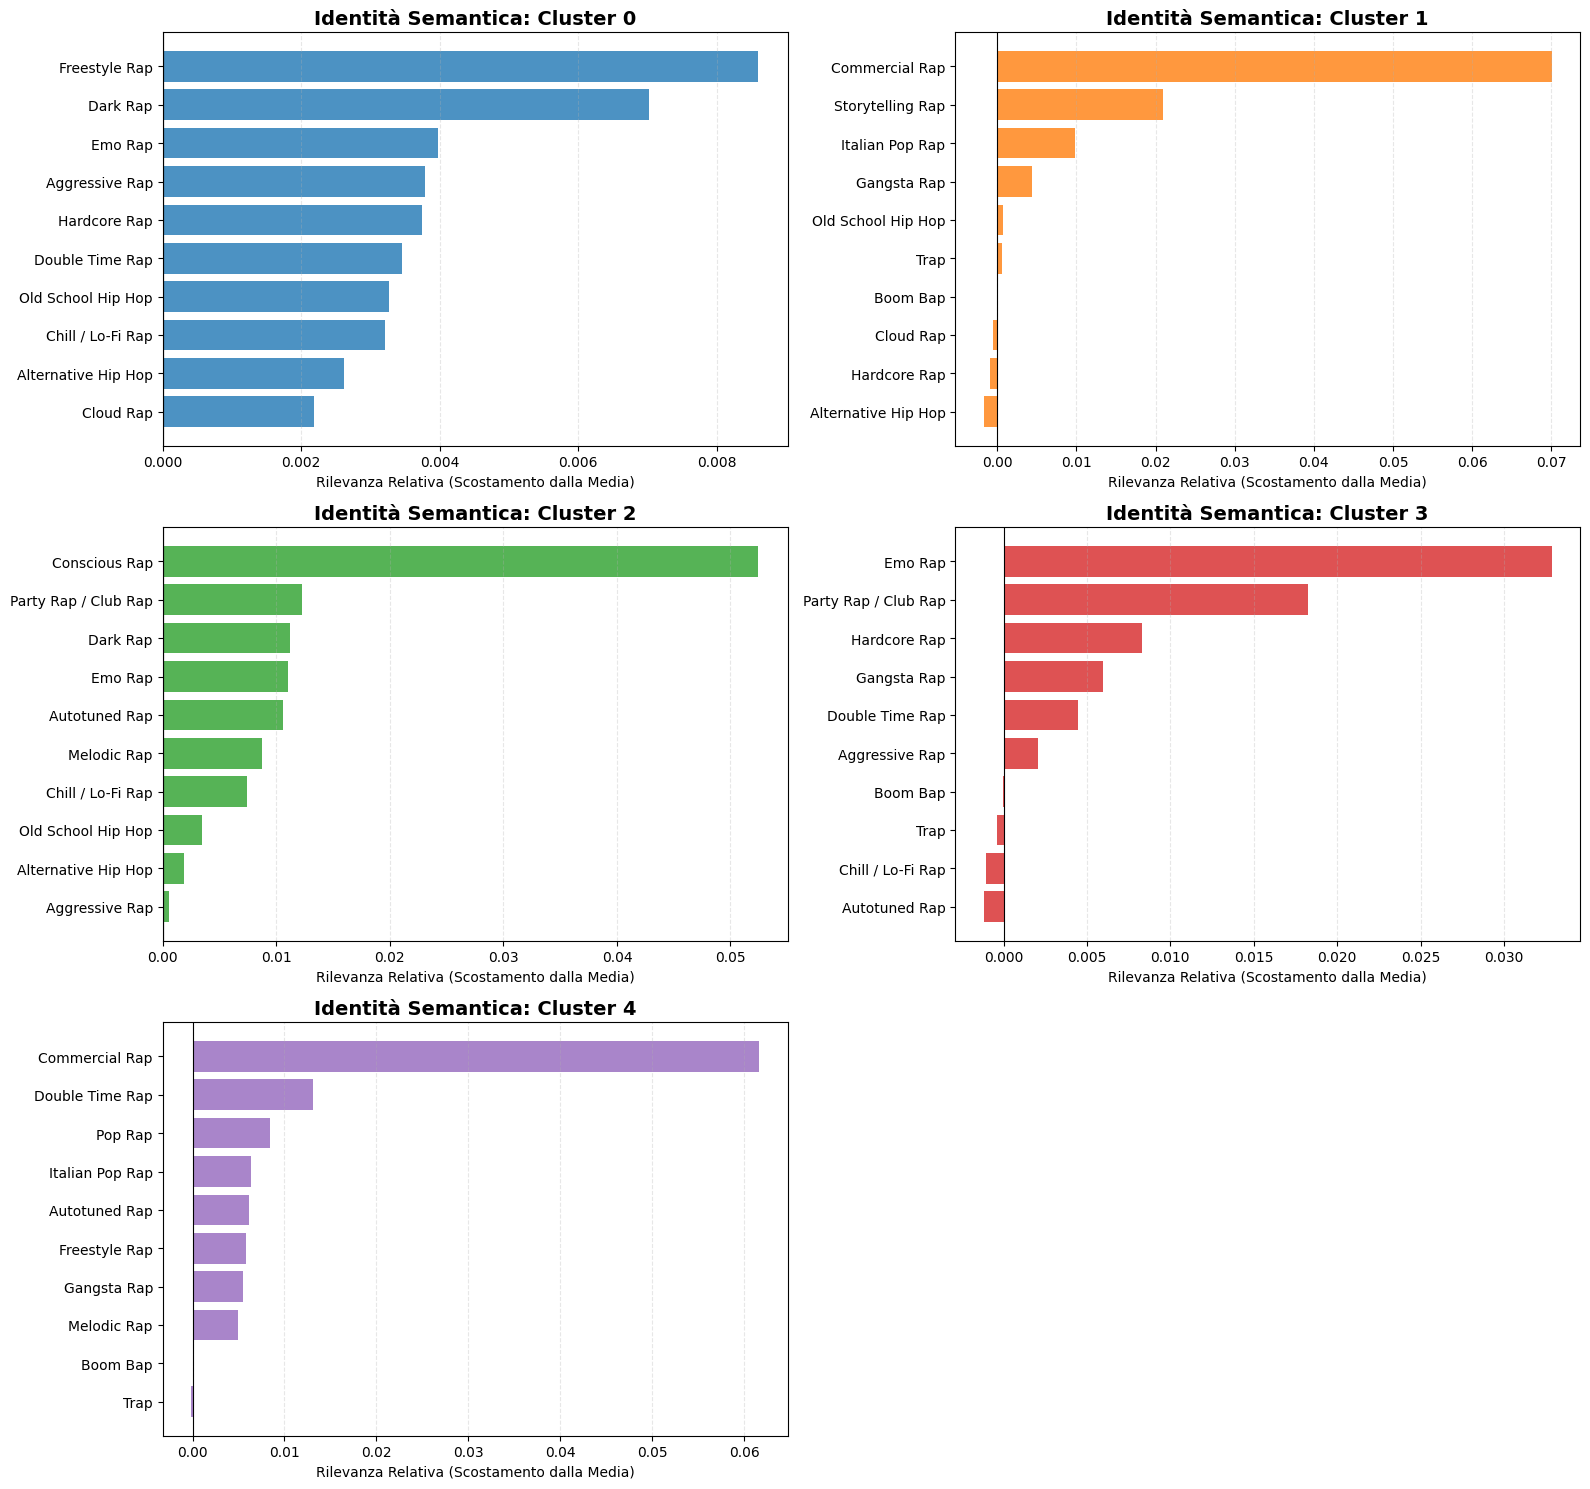

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

all_means = np.array([d["Style"] for d in cluster_prompt_means])
global_style_mean = np.mean(all_means, axis=0)

n_clusters = len(cluster_prompt_means)
cols = 2
rows = (n_clusters + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
axes = axes.flatten()
cmap = plt.get_cmap('tab10') 

for i in range(n_clusters):
    ax = axes[i]
    
    relevance = cluster_prompt_means[i]["Style"] - global_style_mean
    
    top_indices = np.argsort(relevance)[-10:]
    top_labels = [rap_styles[idx] for idx in top_indices]
    top_values = relevance[top_indices]
    
    color = cmap(i % 10)
    ax.barh(top_labels, top_values, color=color, alpha=0.8)
    
    ax.set_title(f"Semantic Identity: Cluster {i}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Relative Relevance (Deviation from Mean)")
    ax.axvline(0, color='black', linewidth=0.8)
    ax.grid(axis='x', linestyle='--', alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

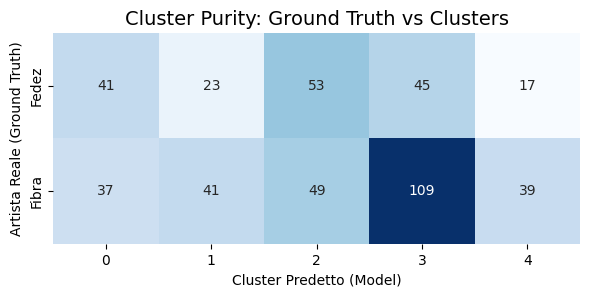

Cluster Predetto (Model),0,1,2,3,4
Artista Reale (Ground Truth),,,,,
Fedez,41,23,53,45,17
Fibra,37,41,49,109,39


In [ ]:
true_labels = ["Fedez" if f in fedez_files else "Fibra" for f in all_files]
plot_cluster_purity(true_labels, predicted_clusters)

In [274]:

extractor = FeatureExtractor(model_ids=["facebook/wav2vec2-base"], sampling_rates=[16000])
all_features = []

for file_path in tqdm(all_files):
    features = extractor.extract_features(
        file_path=file_path,
        cache_dir="../extracted_features"  
    )
    all_features.append(features)

# Resampling
target_length = 500
resampler = TimeSeriesResampler(sz=target_length)
X_resampled = resampler.fit_transform(all_features)  # shape: (n_songs, 500, 768)


100%|██████████| 454/454 [00:20<00:00, 22.32it/s]


In [275]:
X_global = X_resampled.std(axis=1)
print(X_global.shape)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import Normalizer
import numpy as np

print(f"Shape originale: {X_global.shape}")

normalizer = Normalizer()
X_norm = normalizer.fit_transform(X_global)

pca = PCA(n_components=0.9) # Tieni il 95% della varianza
X_pca = pca.fit_transform(X_norm)

print(f"Ridotto a {X_pca.shape[1]} dimensioni (componenti).")

(454, 768)
Shape originale: (454, 768)
Ridotto a 90 dimensioni (componenti).


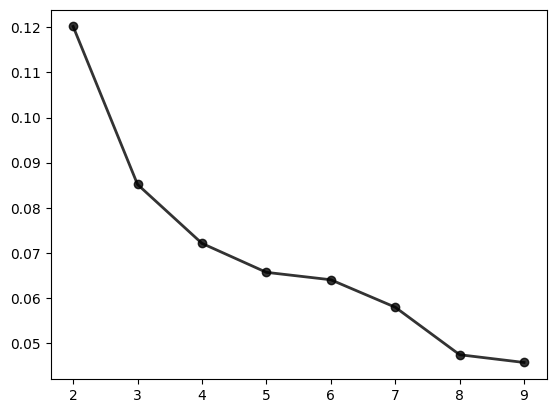

In [276]:
from sklearn.metrics import silhouette_score, adjusted_rand_score, classification_report, confusion_matrix

scores = []
k_values = range(2,10)
for i in k_values:
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    predicted_clusters = kmeans.fit_predict(X_pca)
    scores.append(silhouette_score(X_pca, predicted_clusters))


fig, axes = plt.subplots()
plt.plot(k_values, scores, marker='o', color='black', linestyle='-', linewidth=2, alpha=0.8)
plt.show()

In [277]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
predicted_clusters = kmeans.fit_predict(X_pca)

print("Clustering completato.")

Clustering completato.


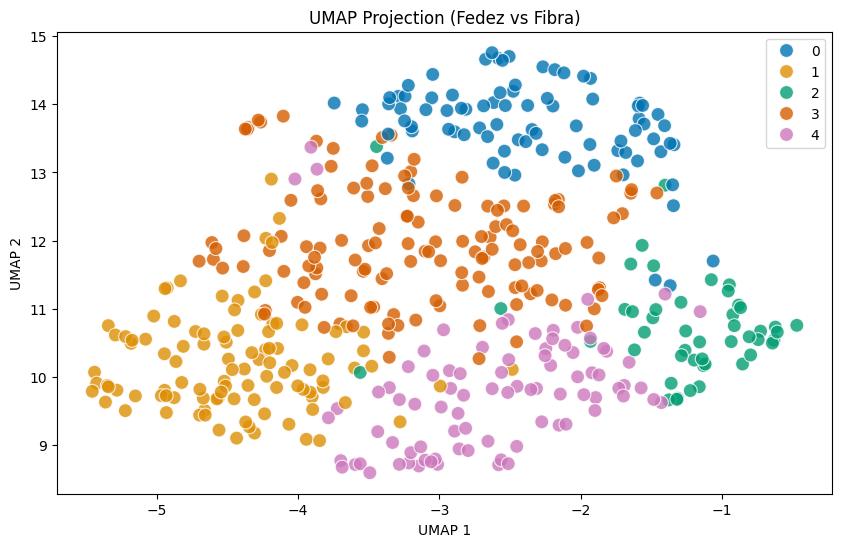

In [278]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns


reducer = umap.UMAP(
    n_neighbors=30,   
    min_dist=0.1, 
    n_components=2, 
    random_state=42
)

X_umap = reducer.fit_transform(X_pca)

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_umap[:, 0], 
    y=X_umap[:, 1], 
    hue=predicted_clusters, 
    palette='colorblind',
    s=100,
    legend='full',
    alpha=0.8 # Aggiungo trasparenza per vedere le sovrapposizioni
)
plt.title('UMAP Projection (Fedez vs Fibra)')
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

### Cluster Interpretability

In [ ]:
from transformers import ClapModel, ClapProcessor
model = ClapModel.from_pretrained("laion/clap-htsat-unfused")
processor = ClapProcessor.from_pretrained("laion/clap-htsat-unfused")

rap_styles = [
    "Hardcore Rap",
    "Old School Hip Hop",
    "Boom Bap",
    "Conscious Rap",
    "Storytelling Rap",
    "Aggressive Rap",
    "Double Time Rap",
    "Freestyle Rap",
    "Gangsta Rap",
    
    "Pop Rap",
    "Melodic Rap",
    "Commercial Rap",
    "Party Rap / Club Rap",
    "Autotuned Rap",
    "Italian Pop Rap",
    
    "Trap",
    "Cloud Rap",
    "Emo Rap",
    "Dark Rap",
    "Alternative Hip Hop",
    "Chill / Lo-Fi Rap"
]

structure_labels = [
    "Very repetitive sections",
    "Clear verse-chorus structure",
    "Evolving sections with noticeable changes",
    "Chaotic or fragmented structure",
    "Gradual build-up increasing intensity",
    "Minimal variation, repetitive loops",
    "Choruses differ significantly from verses"
]

density_labels = [
    "Very dense, many overlapping layers",
    "Moderately dense, balanced elements",
    "Sparse, few instruments, lots of space",
    "Alternating sparse and dense sections",
    "Cluttered with overlapping melodic/percussive elements",
    "Very light instrumentation, focus on silence/space"
]

voice_balance_labels = [
    "Vocals clearly dominant",
    "Instrumental dominant with vocals blended",
    "Vocals and instrumental equally balanced",
    "Vocals dominate only in choruses",
    "Vocals blend in the background",
    "Vocals prominent in some passages, minimal in others"
]

tempo_perception_labels = [
    "Fast and urgent",
    "Steady, moderate pacing",
    "Slow or stretched",
    "Variable tempo within sections",
    "Mostly slow with occasional bursts",
    "Irregular or syncopated, hard to perceive steady beat"
]

def clap_classify(labels, y, sr):
    inputs = processor(
        text=labels,
        audio=y,
        return_tensors="pt",
        padding=True,
        sampling_rate=sr
    )
    outputs = model(**inputs)
    probs = outputs.logits_per_audio.softmax(dim=1)
    return probs[0]


In [ ]:
sr = 48000

cluster_prompt_means = []

for cluster_idx, cluster in enumerate(cluster_samples):
    cluster_dict = {}
    
    for name, labels in [
        ("Style", rap_styles),
        ("Structure", structure_labels),
        ("Density", density_labels),
        ("VoiceBalance", voice_balance_labels),
        ("TempoPerception", tempo_perception_labels)
    ]:
        probs_list = []

        
        for song_idx in cluster:
            y, sr = librosa.load(all_files[song_idx], sr=48000)
            probs = clap_classify(labels, y, sr) 
            probs_list.append(probs.detach().cpu().numpy())  

        mean_probs = np.mean(np.stack(probs_list), axis=0)  
        cluster_dict[name] = mean_probs

    cluster_prompt_means.append(cluster_dict)

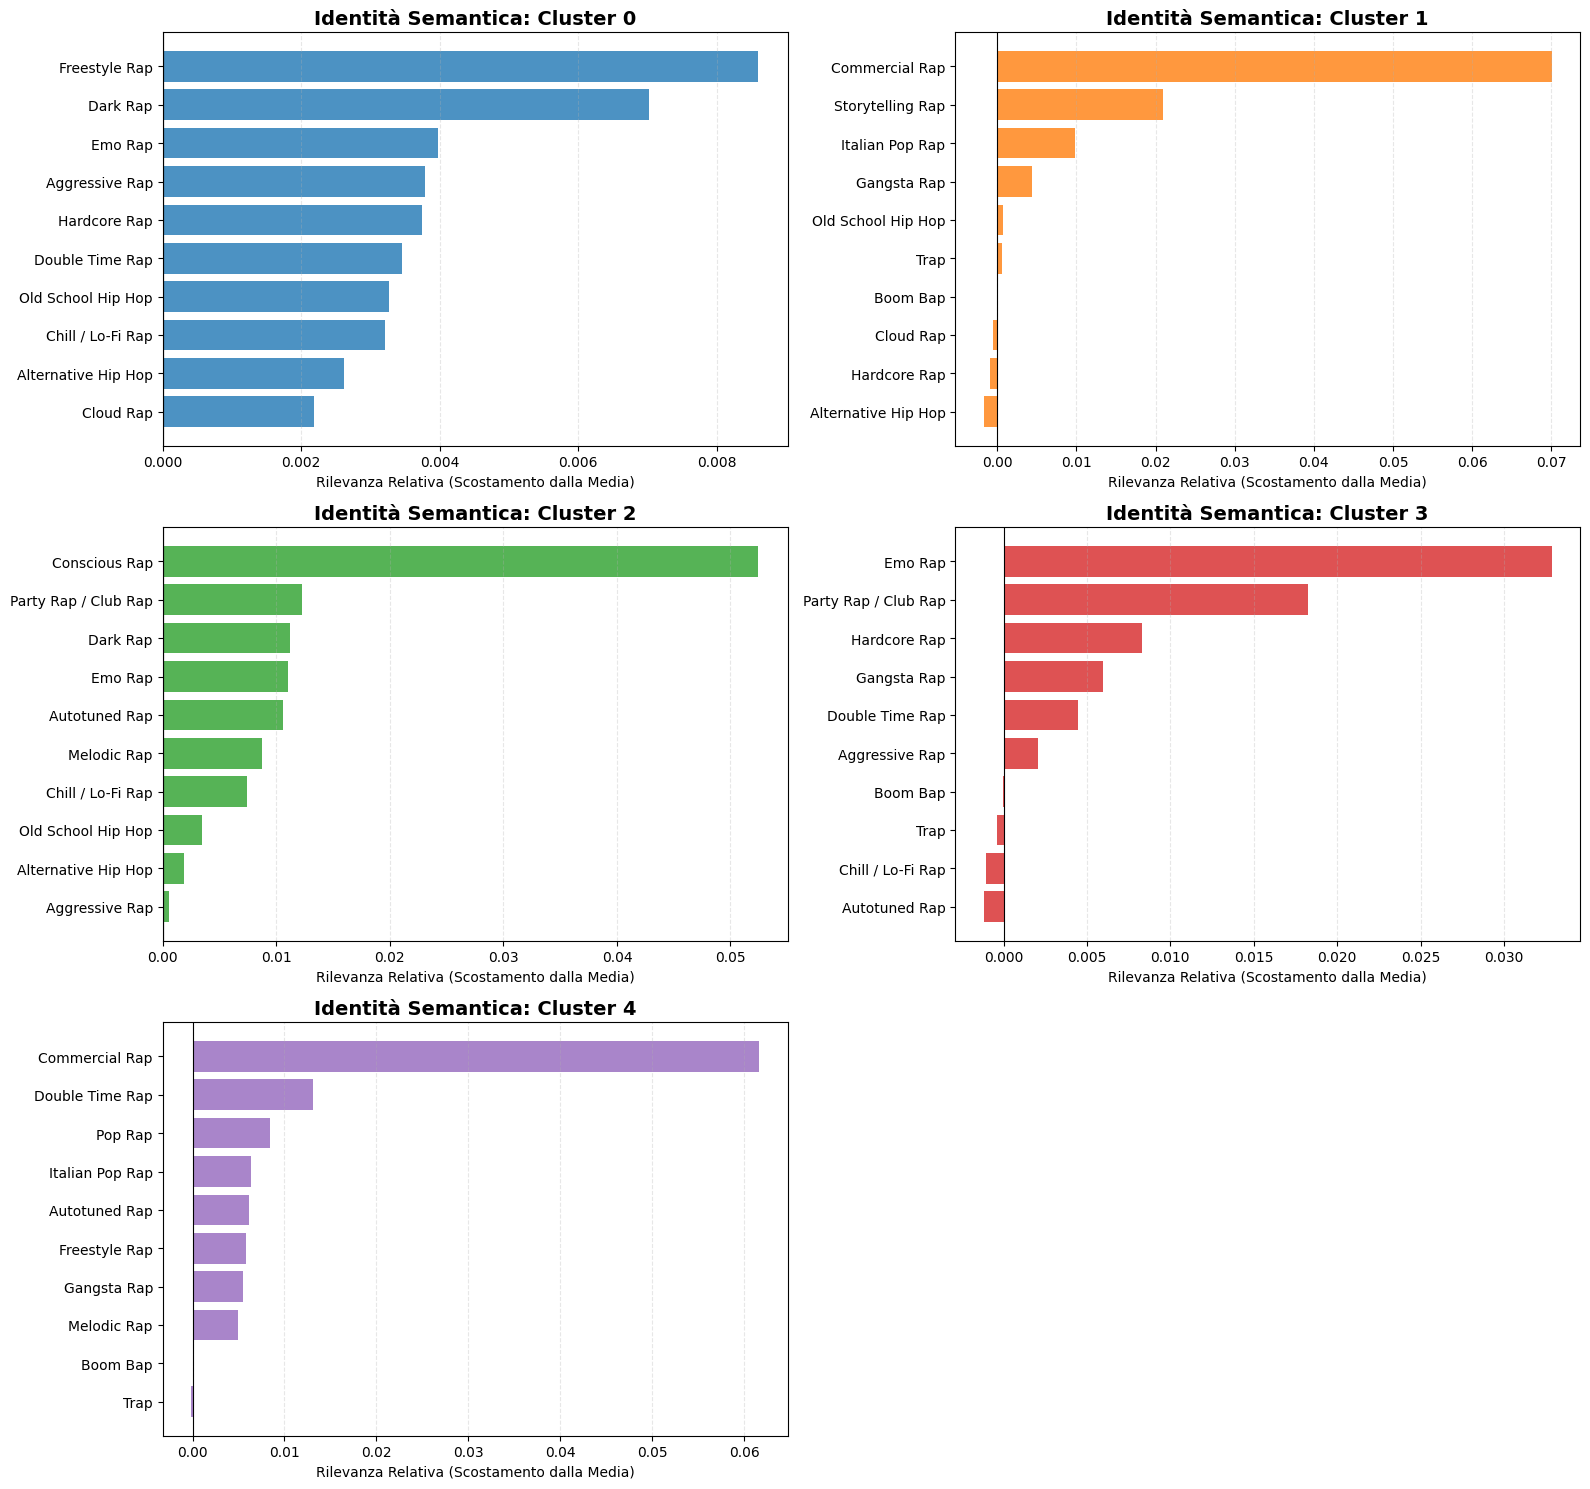

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

all_means = np.array([d["Style"] for d in cluster_prompt_means])
global_style_mean = np.mean(all_means, axis=0)

n_clusters = len(cluster_prompt_means)
cols = 2
rows = (n_clusters + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
axes = axes.flatten()
cmap = plt.get_cmap('tab10') 

for i in range(n_clusters):
    ax = axes[i]
    
    relevance = cluster_prompt_means[i]["Style"] - global_style_mean
    
    top_indices = np.argsort(relevance)[-10:]
    top_labels = [rap_styles[idx] for idx in top_indices]
    top_values = relevance[top_indices]
    
    color = cmap(i % 10)
    ax.barh(top_labels, top_values, color=color, alpha=0.8)
    
    ax.set_title(f"Semantic Identity: Cluster {i}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Relative Relevance (Deviation from Mean)")
    ax.axvline(0, color='black', linewidth=0.8)
    ax.grid(axis='x', linestyle='--', alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

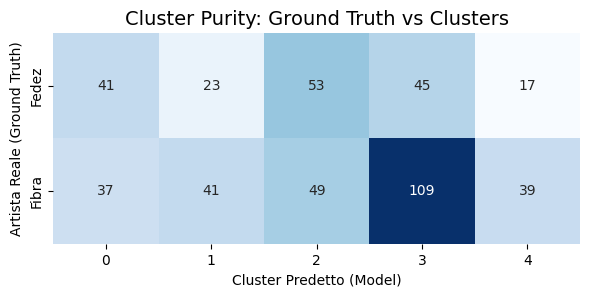

Cluster Predetto (Model),0,1,2,3,4
Artista Reale (Ground Truth),,,,,
Fedez,41,23,53,45,17
Fibra,37,41,49,109,39


In [ ]:
true_labels = ["Fedez" if f in fedez_files else "Fibra" for f in all_files]
plot_cluster_purity(true_labels, predicted_clusters)

## Clustering with DTW on MERT embeddings

In [279]:
# Preparazione per PCA (Flattening)
n_songs, n_time, n_feat = X_resampled.shape
X_flat = X_resampled.reshape(n_songs * n_time, n_feat)

# PCA
pca = PCA(n_components=5)
mask = ~np.isnan(X_flat).any(axis=1)

X_valid = X_flat[mask]
X_pca_valid = pca.fit_transform(X_valid)

X_pca_full = np.full((X_flat.shape[0], pca.n_components_), np.nan)
X_pca_full[mask] = X_pca_valid

# Reshape e Scaling
X_pca = X_pca_full.reshape(n_songs, n_time, -1)
scaler = TimeSeriesScalerMeanVariance()
X_scaled = scaler.fit_transform(X_pca)

# Clustering
kmeans = TimeSeriesKMeans(
    n_clusters=2,
    metric="softdtw", 
    metric_params={"gamma": 0.5}, 
    max_iter=10,
    random_state=42,
    verbose=True,
    n_jobs=-1
)
predicted_clusters = kmeans.fit_predict(X_scaled)

8994724.177 --> 

KeyboardInterrupt: 

In [ ]:
print(X_scaled.shape)

(200, 500, 5)


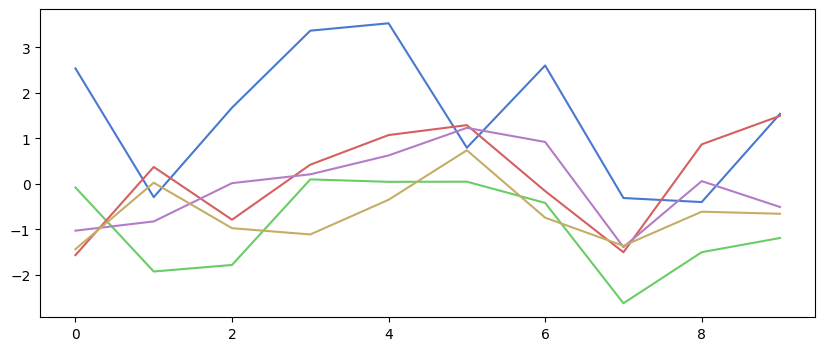

In [ ]:
# Usa 'subplots' (plurale) che è più moderno e pulito
fig, ax = plt.subplots(1, 1, figsize=(10, 4)) 

# Niente [0], usi 'ax' direttamente
ax.plot(X_scaled[0][:10]) 

plt.show()

In [ ]:
print(pca.n_components_)

5


IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

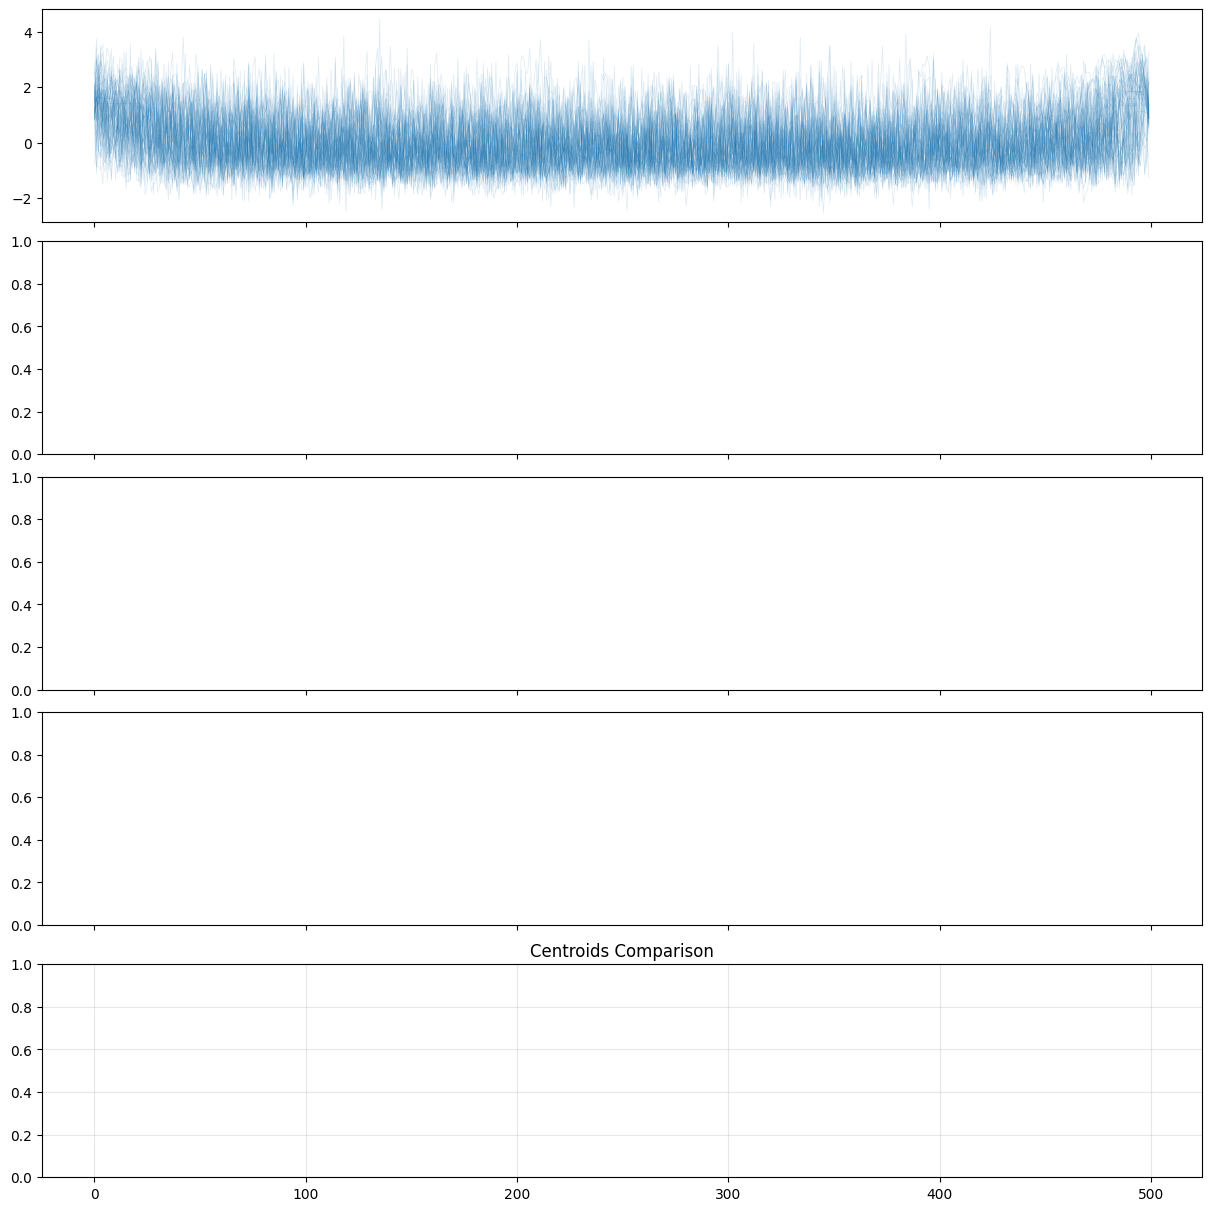

In [ ]:
plot_timeseries_clusters(X_scaled, predicted_clusters, centroids=kmeans.cluster_centers_, feature_idx=0, title="Time Series Clustering Baseline")


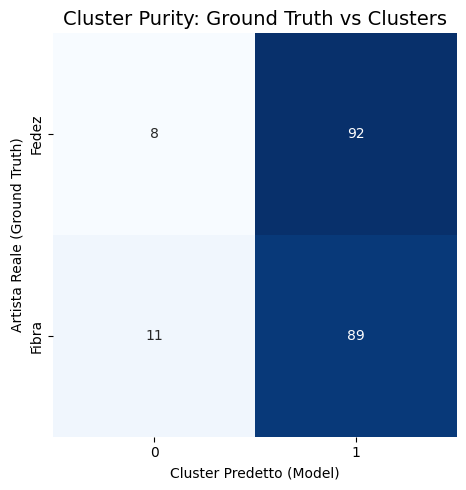

Cluster Predetto (Model),0,1
Artista Reale (Ground Truth),,
Fedez,8,92
Fibra,11,89


In [ ]:
true_labels = ["Fedez" if f in fedez_files else "Fibra" for f in all_files]
plot_cluster_purity(true_labels, predicted_clusters)

Feature-based clustering

In [ ]:
from scipy import stats
def calculate_features(values):
    features = {
        'avg': np.mean(values),
        'std': np.std(values),
        'var': np.var(values),
        'med': np.median(values),
        '10p': np.percentile(values, 10),
        '25p': np.percentile(values, 25),
        '50p': np.percentile(values, 50),
        '75p': np.percentile(values, 75),
        '90p': np.percentile(values, 90),
        'iqr': np.percentile(values, 75) - np.percentile(values, 25),
        'cov': 1.0 * np.mean(values) / np.std(values),
        'skw': stats.skew(values),
        'kur': stats.kurtosis(values)
    }

    return features

F = [list(calculate_features(x).values())[:-2] for x in X_scaled]

Calcolo inerzia per KMeans standard (su Features F)...


100%|██████████| 8/8 [00:00<00:00, 106.71it/s]


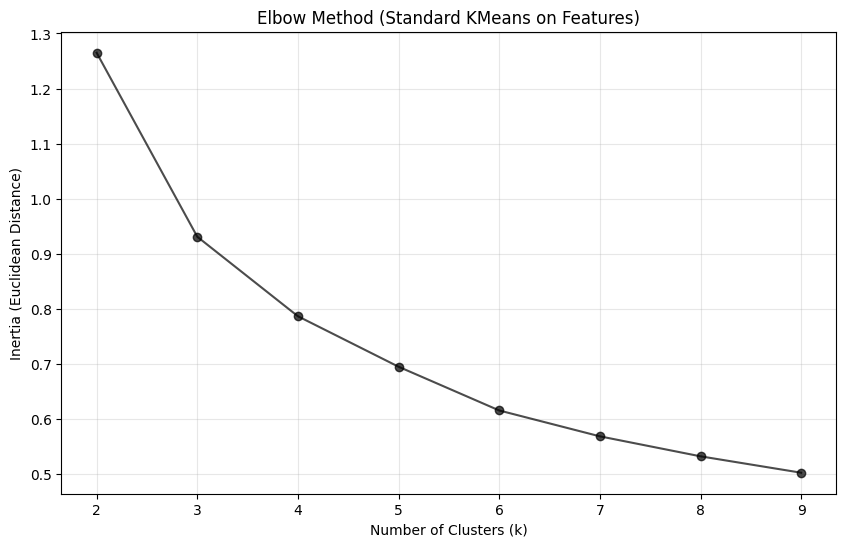

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from tqdm import tqdm

# Range dei cluster da testare
k_values = range(2, 10)
scores = []

print("Calcolo inerzia per KMeans standard (su Features F)...")

for k in tqdm(k_values):
    kmeans = KMeans(
        n_clusters=k,
        max_iter=300,    # Default standard è meglio
        n_init=10,       # 10 è più robusto per evitare minimi locali
        verbose=False,
        random_state=42
    )

    kmeans.fit(F)

    scores.append(kmeans.inertia_)
    
plt.figure(figsize=(10, 6))

plt.plot(k_values, scores, marker='o', linestyle='-', color='black', alpha=0.7)

plt.title("Elbow Method (Standard KMeans on Features)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Euclidean Distance)")
plt.grid(True, alpha=0.3)
plt.xticks(k_values) # Mostra tutti i numeri interi sull'asse X

plt.show()

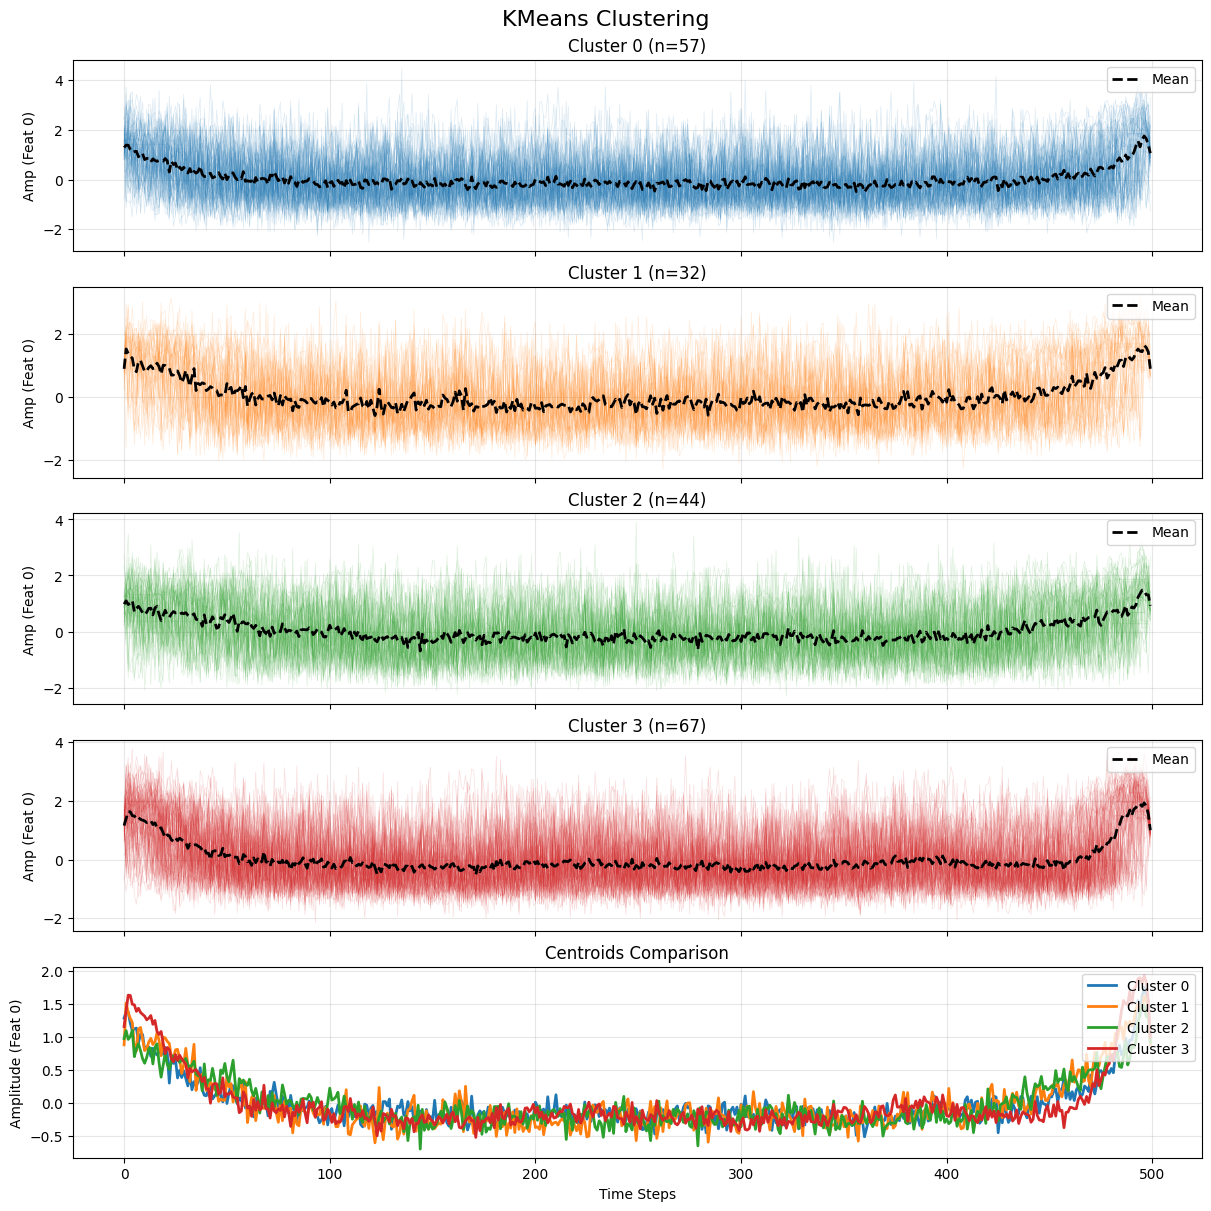

In [ ]:
from sklearn.cluster import KMeans
from utils import plot_timeseries_clusters
kmeans = KMeans(n_clusters=4, n_init=10)
kmeans.fit(F)
predicted_clusters = kmeans.predict(F)
pca_1dim = PCA(n_components=1)
univariate_data = pca_1dim.fit_transform(F)

plot_timeseries_clusters(X_scaled, predicted_clusters, title="KMeans Clustering")

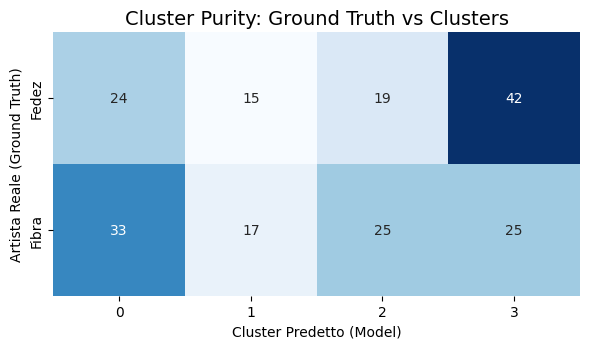

Cluster Predetto (Model),0,1,2,3
Artista Reale (Ground Truth),,,,
Fedez,24,15,19,42
Fibra,33,17,25,25


In [ ]:
true_labels = ["Fedez" if f in fedez_files else "Fibra" for f in all_files]
plot_cluster_purity(true_labels, predicted_clusters)

K-Distance Graph

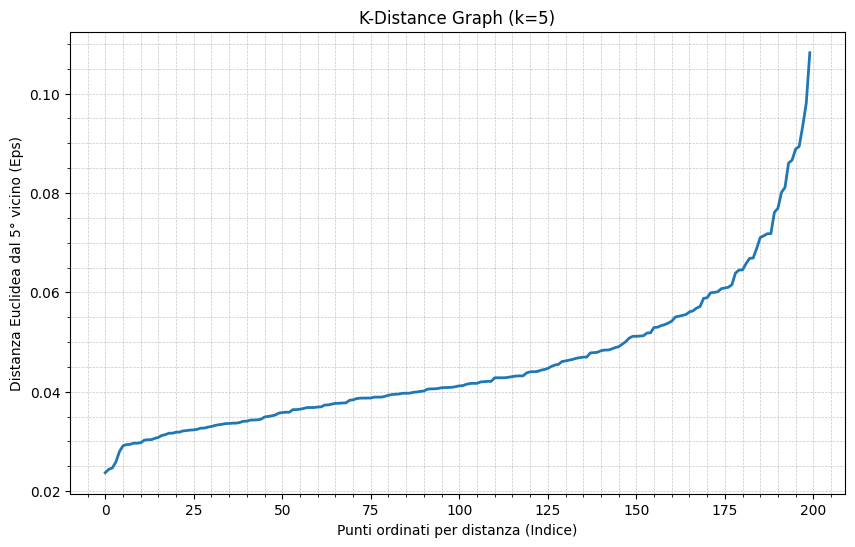

Istruzioni: Cerca il punto di massima curvatura (il 'gomito').
Il valore Y corrispondente è un buon punto di partenza per 'eps'.


In [ ]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

k_neighbors = 5 

neighbors = NearestNeighbors(n_neighbors=k_neighbors)
neighbors_fit = neighbors.fit(F)
distances, indices = neighbors_fit.kneighbors(F)

sorted_distances = np.sort(distances[:, k_neighbors-1], axis=0)

# --- PLOT ---
plt.figure(figsize=(10, 6))
plt.plot(sorted_distances, color='#1f77b4', linewidth=2)
plt.title(f"K-Distance Graph (k={k_neighbors})")
plt.xlabel("Punti ordinati per distanza (Indice)")
plt.ylabel(f"Distanza Euclidea dal {k_neighbors}° vicino (Eps)")

# Griglia fitta per leggere meglio il valore Y
plt.grid(which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.minorticks_on()

plt.show()

print("Istruzioni: Cerca il punto di massima curvatura (il 'gomito').")
print("Il valore Y corrispondente è un buon punto di partenza per 'eps'.")

Avvio DBSCAN con eps=0.12 e min_samples=5...

--- Risultati Clustering ---
Cluster trovati: 1
Punti di Rumore (Outliers): 0


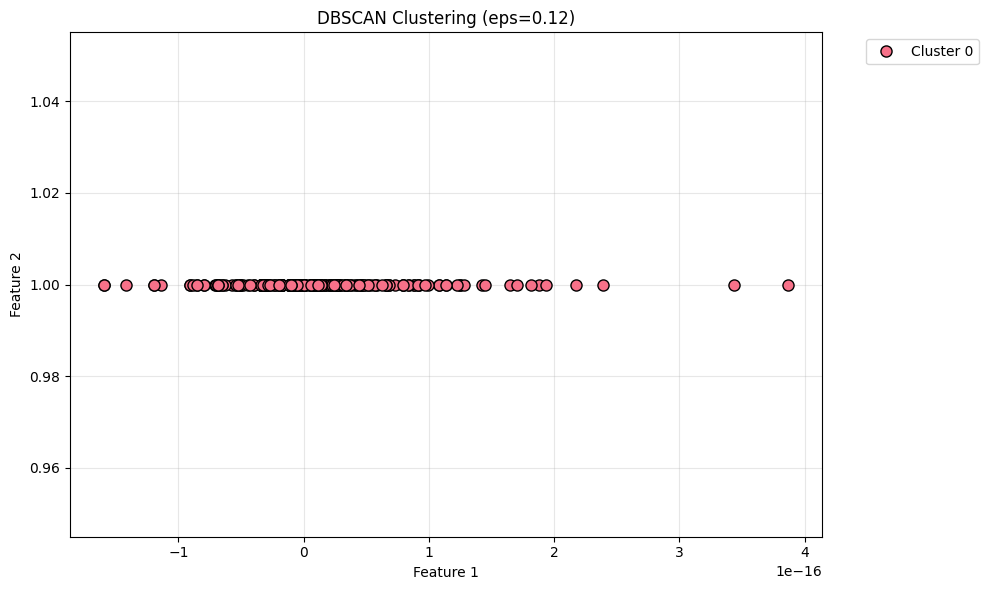

In [ ]:
from sklearn.cluster import DBSCAN
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- CORREZIONE FONDAMENTALE ---
# Convertiamo F in un array Numpy, altrimenti il filtro [class_member_mask] fallisce
F = np.array(F) 
# -------------------------------

# 1. Configurazione DBSCAN
eps_value = 0.12
min_samples_value = k_neighbors 

print(f"Avvio DBSCAN con eps={eps_value} e min_samples={min_samples_value}...")

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
labels_dbscan = dbscan.fit_predict(F)

# 2. Statistiche dei Risultati
n_clusters_ = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise_ = list(labels_dbscan).count(-1)

print(f"\n--- Risultati Clustering ---")
print(f"Cluster trovati: {n_clusters_}")
print(f"Punti di Rumore (Outliers): {n_noise_}")

# 3. Visualizzazione (Scatter Plot 2D)
plt.figure(figsize=(10, 6))

unique_labels = set(labels_dbscan)
colors = sns.color_palette("husl", len(unique_labels))

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Colore Nero per il Rumore
        col = (0, 0, 0)
        marker = 'x'
        label_name = "Noise (-1)"
        alpha = 0.3 
    else:
        marker = 'o'
        label_name = f"Cluster {k}"
        alpha = 1.0

    class_member_mask = (labels_dbscan == k)
    
    # ORA FUNZIONA: F è un numpy array, quindi accetta la maschera booleana
    xy = F[class_member_mask]
    
    plt.plot(xy[:, 0], xy[:, 1], marker, markerfacecolor=col,
             markeredgecolor='k', markersize=8, alpha=alpha, label=label_name)

plt.title(f'DBSCAN Clustering (eps={eps_value})')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Silhouette Score Grid Search

Inizio Grid Search su 50 valori di eps...


100%|██████████| 50/50 [00:00<00:00, 477.89it/s]


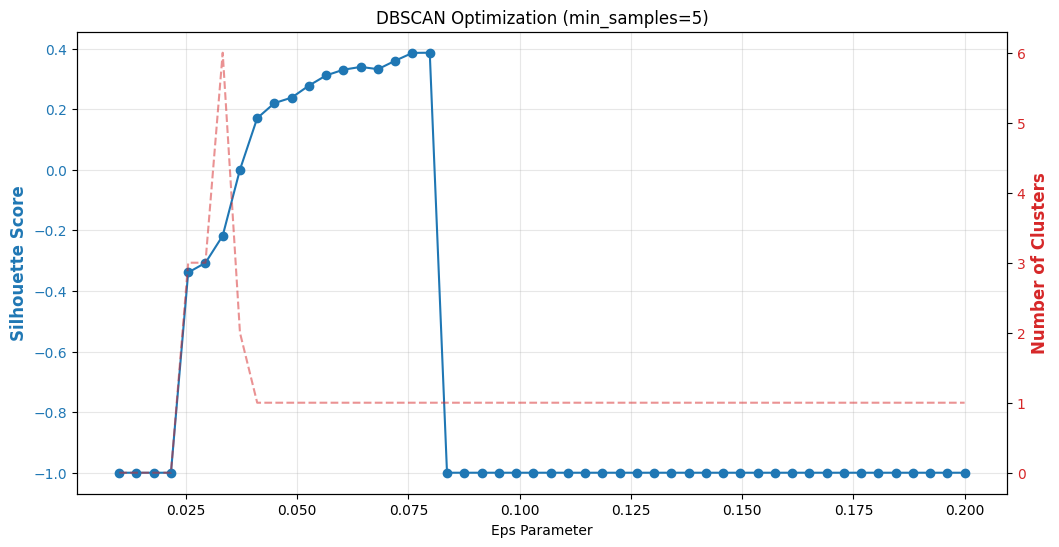

--- MIGLIOR CONFIGURAZIONE TROVATA (con almeno 2 cluster) ---
Eps ottimale:      0.037
Silhouette Score:  0.000
Cluster trovati:   2
Rumore (Noise):    38.5%


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- CONFIGURAZIONE ---
eps_range = np.linspace(0.01, 0.20, 50)  # Range da testare (modificalo in base al grafico sopra!)
min_samples_val = 5                    # Lo teniamo fisso per semplificare il plot 2D

results = []

print(f"Inizio Grid Search su {len(eps_range)} valori di eps...")

for eps in tqdm(eps_range):
    # 1. Fit DBSCAN
    db = DBSCAN(eps=eps, min_samples=min_samples_val)
    labels = db.fit_predict(F)
    
    # 2. Analisi Risultati
    # Contiamo i cluster (escludendo il rumore -1)
    unique_labels = set(labels)
    n_clusters = len(unique_labels) - (1 if -1 in labels else 0)
    
    # Calcoliamo % di rumore
    noise_ratio = np.sum(labels == -1) / len(labels)
    
    # Il Silhouette Score richiede almeno 2 label distinte (es. 2 cluster, oppure 1 cluster + rumore)
    # Se DBSCAN trova solo 1 gruppo o tutto rumore, score non è calcolabile.
    if len(unique_labels) > 1:
        score = silhouette_score(F, labels)
    else:
        score = -1.0 # Penalizziamo le configurazioni inutili
        
    results.append({
        'eps': eps,
        'silhouette': score,
        'n_clusters': n_clusters,
        'noise_ratio': noise_ratio
    })

# Convertiamo in DataFrame per facilità di analisi
df_res = pd.DataFrame(results)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Silhouette (Asse Y Sinistro)
color = 'tab:blue'
ax1.set_xlabel('Eps Parameter')
ax1.set_ylabel('Silhouette Score', color=color, fontsize=12, fontweight='bold')
ax1.plot(df_res['eps'], df_res['silhouette'], color=color, marker='o', label='Silhouette')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Number of Clusters', color=color, fontsize=12, fontweight='bold')
ax2.plot(df_res['eps'], df_res['n_clusters'], color=color, linestyle='--', alpha=0.5, label='N Clusters')
ax2.tick_params(axis='y', labelcolor=color)

plt.title(f"DBSCAN Optimization (min_samples={min_samples_val})")
plt.show()

valid_results = df_res[df_res['n_clusters'] >= 2]

if not valid_results.empty:
    best_row = valid_results.loc[valid_results['silhouette'].idxmax()]
    print("--- MIGLIOR CONFIGURAZIONE TROVATA (con almeno 2 cluster) ---")
    print(f"Eps ottimale:      {best_row['eps']:.3f}")
    print(f"Silhouette Score:  {best_row['silhouette']:.3f}")
    print(f"Cluster trovati:   {int(best_row['n_clusters'])}")
    print(f"Rumore (Noise):    {best_row['noise_ratio']*100:.1f}%")



NCD based clustering

In [ ]:
import zlib
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from tqdm import tqdm

# --- 1. Definizione della metrica CDM (Compression-based Dissimilarity Measure) ---
def cdm_dist(x, y):
    # Convertiamo i dati in stringa di byte per zlib
    # Usiamo f-string con precisione per coerenza
    x_str = (' '.join([f"{v:.5f}" for v in x.ravel()])).encode('utf-8')
    y_str = (' '.join([f"{v:.5f}" for v in y.ravel()])).encode('utf-8')
    
    # Calcolo compressioni
    len_x = len(zlib.compress(x_str))
    len_y = len(zlib.compress(y_str))
    len_xy = len(zlib.compress(x_str + y_str))
    
    # Formula CDM
    return len_xy / (len_x + len_y)

# --- 2. Pre-calcolo della Matrice delle Distanze ---
print("Calcolo della matrice delle distanze CDM (potrebbe richiedere tempo)...")

# FIX CRITICO: pdist richiede una matrice 2D (n_samples, n_features).
# X_scaled è 3D (n_songs, n_time, n_features).
# Dobbiamo appiattirlo in 2D.
n_samples = X_scaled.shape[0]
X_flattened = X_scaled.reshape(n_samples, -1)

print(f"Shape originale: {X_scaled.shape}")
print(f"Shape input per pdist: {X_flattened.shape}")

# pdist calcola le distanze a coppie usando la tua funzione custom
distance_vector = pdist(X_flattened, metric=cdm_dist)
distance_matrix = squareform(distance_vector)

print("Matrice calcolata. Shape:", distance_matrix.shape)

# --- 3. Ricerca del Clustering Ottimale ---
k_values = range(2, 6) # Range ridotto per test rapido, aumentalo a 10 se vuoi
scores = []

print("Test clustering per vari k...")
for k in tqdm(k_values):
    # 'metric'='precomputed' dice al modello di usare la matrice delle distanze
    model = AgglomerativeClustering(
        n_clusters=k, 
        metric='precomputed', 
        linkage='average' 
    )
    
    labels = model.fit_predict(distance_matrix)
    
    # Calcolo Silhouette Score con la metrica precomputata
    if len(set(labels)) > 1:
        score = silhouette_score(distance_matrix, labels, metric='precomputed')
    else:
        score = -1
        
    scores.append(score)

# --- 4. Plotting dei Risultati ---
plt.figure(figsize=(10, 6))
plt.plot(k_values, scores, marker='o', color='#d62728', linewidth=2)
plt.title("Optimization using CDM (Compression Distance)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score (CDM Metric)")
plt.grid(True, alpha=0.3)
plt.xticks(k_values)

# Evidenzia il miglior K
if len(scores) > 0:
    best_idx = np.argmax(scores)
    best_k = k_values[best_idx]
    best_score = scores[best_idx]
    plt.axvline(best_k, color='black', linestyle='--', alpha=0.5, label=f'Best k={best_k}')
    
    print(f"Miglior numero di cluster (k): {best_k}")
    print(f"Miglior Silhouette Score: {best_score:.4f}")

plt.legend()
plt.show()


Calcolo della matrice delle distanze CDM (potrebbe richiedere tempo)...
Shape originale: (200, 500, 5)
Shape input per pdist: (200, 2500)


KeyboardInterrupt: 

### Visualize Centroids (Motifs)
The cluster centroids represent the "average" song in that cluster, effectively capturing the **motif** or common pattern of that group.

In [ ]:
plt.figure(figsize=(12, 6))
for i, centroid in enumerate(km.cluster_centers_):
    plt.subplot(1, 2, i + 1)
    # Visualize first MFCC coefficient (Energy/Loudness approx) and maybe another
    plt.plot(centroid[:, 0], label='MFCC 0 (Loudness)')
    plt.plot(centroid[:, 1], label='MFCC 1 (Timbre)', alpha=0.7)
    plt.title(f"Cluster {i} Centroid")
    plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'km' is not defined

<Figure size 1200x600 with 0 Axes>

### Anomaly Detection
We identify anomalies as the songs that are furthest from their cluster centroid.

In [ ]:
# Calculate distances to assigned centroid
distances = []
for i in range(len(X_scaled)):
    cluster_idx = labels[i]
    centroid = km.cluster_centers_[cluster_idx]
    # Euclidean distance
    dist = np.linalg.norm(X_scaled[i] - centroid)
    distances.append(dist)

df_res['Distance'] = distances

# Top 5 Anomalies
anomalies = df_res.sort_values('Distance', ascending=False).head(5)
print("Top 5 Anomalies (Furthest from centroid):")
print(anomalies)

## 6. Shapelet Extraction (Task 4.2)
We use **LearningShapelets** to find shapelets (discriminative subsequences) that best separate Fedez from Fabri Fibra.

In [ ]:
# Prepare labels for classification
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Define Shapelet Model
print("Training Shapelet Model (this may take a while)...")
# Only using a few shapelets for speed demonstration
shp_clf = LearningShapelets(
    n_shapelets_per_size={50: 3}, 
    max_iter=50,
    verbose=1,
    optimizer="adam",
    scale=False,
    random_state=42
)

shp_clf.fit(X_scaled, y_enc)
print("Shapelet training complete.")

# Predictions
y_pred = shp_clf.predict(X_scaled)
print(f"Accuracy: {accuracy_score(y_enc, y_pred):.2f}")

### Visualize Learning Shapelets
We visualize the learned shapelets and where they match in the time series.

In [ ]:
predicted_locations = shp_clf.transform(X_scaled)
shapelet_vis_count = min(3, len(shp_clf.shapelets_as_time_series_))

plt.figure(figsize=(15, 5 * shapelet_vis_count))
for i in range(shapelet_vis_count):
    s = shp_clf.shapelets_as_time_series_[i]
    # Find the best match across all samples
    # transform returns distances. We want to find sample with min distance to this shapelet.
    # Actually transform returns min distances.
    
    # Let's just plot the shapelet itself first (first dimension)
    plt.subplot(shapelet_vis_count, 1, i + 1)
    plt.plot(s[:, 0], label='Shapelet Dim 0 (Loudness)')
    if s.shape[1] > 1:
        plt.plot(s[:, 1], label='Shapelet Dim 1 (Timbre)', alpha=0.6)
    plt.title(f"Shapelet {i}")
    plt.legend()

plt.tight_layout()
plt.show()